In [1]:
import starry
import matplotlib.pyplot as plt
import numpy as np
import pymc3 as pm
import pymc3.math as pmm
import pymc3_ext as pmx
import exoplanet
from starry_process import StarryProcess, MCMCInterface
from starry_process.math import cho_factor, cho_solve
import starry_process 
import theano
theano.config.gcc__cxxflags += " -fexceptions"
theano.config.on_opt_error = "raise"
theano.tensor.opt.constant_folding
theano.graph.opt.EquilibriumOptimizer
import aesara_theano_fallback.tensor as tt
from theano.tensor.slinalg import cholesky
from corner import corner
import arviz as az
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import os
from tqdm import tqdm
from theano.tensor.random.utils import RandomStream
import scipy.linalg as sl
import scipy.stats as ss
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import lightkurve as lk

starry.config.quiet = True
np.random.seed(1)

import warnings

# Ignore all warnings (not recommended, might hide other important warnings)
warnings.filterwarnings("ignore")

# Ignore specific warning by type
warnings.filterwarnings("ignore", message="Cannot construct a scalar test value from a test value with no size")

# Set logging level to ignore these warnings (recommended)
import logging
logger = logging.getLogger("theano.tensor.opt")
logger.setLevel(logging.ERROR)


WARNING (theano.link.c.cmodule): install mkl with `conda install mkl-service`: No module named 'mkl'
The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
/Users/sabina/miniconda3/envs/starry-debug/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/sabina/miniconda3/envs/starry-debug/lib/python3.9/site-packages/lightkurve/config/__init__.py:119: UserWarning: The default Lightkurve cache directory, used by download(), etc., has been moved to /Users/sabina/.lightkurve/cache. Please move all the files in the legacy directory /Users/sabina/.lightkurve-cache to the new location and remove the legacy directory. Refer to https://docs.lightkurve.org/refer

In [2]:
import sys
sys.path.insert(1, '/Users/sabina/Desktop/GitHub/starry/scripts')

from starry_starry_process import StarryStarryProcess

In [3]:
def Inclination(name, testval=30):
    """
    An isotropic distribution for inclination angles (in degrees).
    
    """
    def logp(x):
        return tt.log(np.pi / 180 * tt.sin(x * np.pi / 180))

    def random(*args, **kwargs):
        return tt.arccos(pm.Uniform.dist(0, 1).random(*args, **kwargs)) * 180 / np.pi

    return pm.DensityDist(
        name,
        logp,
        random=random,
        initval=testval,
    )

def Angle(*args, **kwargs):
    """
    A uniform distribution for angles in [-180, 180).
    
    """
    if kwargs.get("testval", None) is not None:
        kwargs["testval"] *= np.pi / 180
    return 180 / np.pi * pmx.Angle(*args, **kwargs)

def Planet_Inc(name, *args, **kwargs):
    bmax = params[name].get('bmax')
    b = pm.Uniform('b', -bmax, bmax)
    planet_inc = pm.Deterministic(name, 180.0/np.pi*np.arccos(b))
    
    return planet_inc

def xyz_transform(x_, y_, z_):
    x = x_
    y = (np.sqrt(2)/2) * (z_ + y_)
    z = (np.sqrt(2)/2) * (z_ - y_)

    return x, y, z

def xyz_transform_back(x, y, z):
    x_ = x
    y_ = (np.sqrt(2)/2) * (y - z)
    z_ = (np.sqrt(2)/2) * (y + z)

    return x_, y_, z_

def Stellar_Ori():
    stellar_ori_x_ = pm.Normal('stellar_ori_x_', mu=0, sigma=1, testval=1)
    stellar_ori_y_ = pm.Normal('stellar_ori_y_', mu=0, sigma=1, testval=1)
    stellar_ori_z_ = pm.HalfNormal('stellar_ori_z_', sigma=1, testval=1)

    stellar_ori_x, stellar_ori_y, stellar_ori_z = xyz_transform(stellar_ori_x_, stellar_ori_y_, stellar_ori_z_)

    stellar_obl = pm.Deterministic('star.obl', 180.0/np.pi*tt.arctan2(stellar_ori_y, stellar_ori_x))
    stellar_inc = pm.Deterministic('star.inc', 180.0/np.pi*tt.arccos(stellar_ori_z / tt.sqrt(tt.square(stellar_ori_x) + tt.square(stellar_ori_y) + tt.square(stellar_ori_z))))
    
    return stellar_inc, stellar_obl
    # if "inc" in name:
    #     return stellar_inc
    
    # elif "obl" in name:
    #     return stellar_obl

def Period(name, *args, **kwargs):
    Ttotal = t[-1] - t[0]
    frac_bounds = params[name].get('frac_bounds')

    if kwargs.get("testval", None) is not None:
        trueval = kwargs["testval"]

    def logp(trueval, frac_bounds):
        return pm.Uniform(name+'logp',tt.log(trueval) + np.log1p(-frac_bounds), tt.log(trueval) + np.log1p(frac_bounds))

    period = pm.Deterministic(name, tt.exp(logp(trueval, frac_bounds)))

    return period

def Logarithmic(name, *args, **kwargs):
    if kwargs.get("testval", None) is not None:
        trueval = kwargs["testval"]
    log_rp = pm.Uniform(name+'log', tt.log(trueval/2), tt.log(2*trueval))
    rp = pm.Deterministic(name, tt.exp(log_rp))

    return rp

# Shorthand for the usual Uniform distribution
Uniform = pm.Uniform

In [4]:
def gp_model(t, flux, sigma_flux, params):
    # Helper function to instantiate parameters
    def parameter(name):
        param = params[name]
        if param.get("free", False):
            args = param.get("args", [])
            kwargs = param.get("kwargs", {})
            testval = param.get("testval", param["truth"])
            return param["dist"](name, *args, testval=testval, **kwargs)
            
        else:
            return param["truth"]
    
    starry.config.lazy = True
        
    with pm.Model() as model:

        prot = parameter('star.prot')

        porb = parameter('planet.porb')
        t0 = parameter('planet.t0')
        rp = parameter('planet.r')
        planet_inc = parameter('planet.inc')
        mp = parameter('planet.m')
        ecc = parameter('planet.ecc')
        Omega = parameter('planet.Omega')
        w = parameter('planet.w')

        map_model = starry.Map(ydeg=15, udeg=2)

        stellar_inc, stellar_obl = Stellar_Ori()
        # map_model.inc = parameter('star.inc')
        # map_model.obl = parameter('star.obl')
        map_model.inc = stellar_inc
        map_model.obl = stellar_obl
        
        map_model[1] = parameter('star.u1')
        map_model[2] = parameter('star.u2')
        
        pri_model = starry.Primary(map_model, 
            r=parameter('star.r'), 
            m=parameter('star.m'), 
            prot=prot)

        sec_model = starry.kepler.Secondary(starry.Map(0,0), 
            t0=t0, 
            r=rp, 
            m=mp, 
            porb=porb, 
            ecc=ecc, 
            Omega=Omega, 
            inc=planet_inc,
            w=w)
    
        sys_model = starry.System(pri_model, sec_model)

        sp_model = StarryProcess(
            a = parameter("gp.a"),
            b = parameter("gp.b"),
            c = parameter("gp.c"),
            r = parameter("gp.r"),
            n = parameter("gp.n"),
            ydeg = 15,
        )
        
        K00 = 0.
        K01 = 10.
        K10 = np.log(0.5)
        K11 = 10.
        alpha = tt.exp(K00 + (K10 - K00) * sp_model.a)
        beta = tt.exp(K10 + (K11 - K10) * sp_model.b) 

        pm.Deterministic('sp.mu', alpha / (alpha + beta) * 180 / np.pi)
        pm.Deterministic('sp.var', alpha * beta / (tt.square(alpha + beta) * (alpha + beta + 1)) * 180 / np.pi)

        loglike = 0.

        
        ssp_model = StarryStarryProcess(sys_model, sp_model)
        ssp_model._compute(t, flux, sigma_flux)
        pm.Deterministic(f'flux_model', tt.dot(ssp_model.design_matrix, ssp_model.sample_ylm_conditional(t, flux, sigma_flux)[0]))
        # pm.Deterministic(f'design_matrix_{i}', tt.constant(ssp_model.design_matrix))
        pm.Deterministic(f'max_map', ssp_model._a)

        loglike = ssp_model.marginal_likelihood(t, flux, sigma_flux)
            
        pm.Potential('marginal_likelihood', loglike)


    return model

In [5]:
def bin_out_of_transit(t, flux, err, params, dt=0.06, binsize=30):
    """
    Bin the out of transit points to speed things up.
    
    """
    # Find in-transit and out-of-transit points
    idx = np.zeros(len(t), dtype=bool)
    ntransits = int(np.ceil(t[-1] / params["planet.porb"]["truth"]))
    for n in range(ntransits):
        t0 = params["planet.t0"]["truth"] + n * params["planet.porb"]["truth"]
        idx |= ((t > t0 - dt) & (t < t0 + dt))
    t_in = t[idx]
    f_in = flux[idx]
    t_out = t[~idx]
    f_out = flux[~idx]

    # Make the size of the out-of-transit array divisible by binsize
    # so we can bin by simple array reshaping
    trim = len(t_out) % binsize
    t_out = t_out[:-trim]
    f_out = f_out[:-trim]

    # We need to be careful not to bin *across* the transit, so
    # let's NaN-out points right _before_ each transit
    f_out[np.where(np.diff(t_out) > 0.1)] = np.nan

    # Bin the out-of-transit data
    t_out = t_out.reshape(-1, binsize).mean(axis=1)
    f_out = f_out.reshape(-1, binsize).mean(axis=1)

    # Remove any nans (the averages *across* transits)
    idx = np.isnan(f_out)
    t_out = t_out[~idx]
    f_out = f_out[~idx]

    # Error arrays
    e_in = err[0] * np.ones_like(t_in)
    e_out = (err[0] / np.sqrt(binsize)) * np.ones_like(t_out)

    # Sort and merge the arrays
    t_ = np.concatenate((t_in, t_out))
    f_ = np.concatenate((f_in, f_out))
    e_ = np.concatenate((e_in, e_out))
    idx = np.argsort(t_)
    t_ = t_[idx]
    flux_ = f_[idx]
    err_ = e_[idx]

    return t_, flux_, err_

In [45]:
# True parameters & priors
params = {
    "planet.inc": {"truth": 90., "dist": Planet_Inc},
    "planet.ecc": {"truth": 0.2, "dist": Uniform, "args": [0.0, 0.5]},
    "planet.Omega": {"truth": 0.0, "dist": Angle},
    "planet.porb": {"truth": 5., "dist": Period},
    "planet.t0": {"truth": 0.5, "dist": Uniform, "args": [-0.6, 0.6]},
    "planet.r": {"truth": 0.04, "dist": Logarithmic},
    "planet.m": {"truth":  1e-3, "dist": Uniform, "args": [1e-4, 1e-2]},
    "planet.w": {"truth": 60, "dist": Angle},

    "star.inc": {"truth": 120, "dist": Stellar_Ori},
    "star.m": {"truth": 1, "dist": Uniform, "args": [0.9,1.1]},
    "star.u1": {"truth": 0.4, "dist": Uniform, "args": [0.0, 0.6]},
    "star.u2": {"truth": 0.26, "dist": Uniform, "args": [0.0, 0.4]},
    "star.prot": {"truth": 30., "dist": Period},
    "star.obl": {"truth": -30, "dist": Stellar_Ori},
    "star.r": {"truth": 1, "dist": Uniform, "args": [0.9,1.1]},

    "gp.a": {"truth": 0.6, "dist": Uniform, "args": [0., 1.]},
    "gp.b": {"truth": 0.2, "dist": Uniform, "args": [0., 1.]},
    "gp.r": {"truth": 10, "dist": Uniform, "args": [5.0, 25.0]},
    "gp.c": {"truth": 0.5, "dist": Uniform, "args": [0.01, 1]},
    "gp.n": {"truth": 3, "dist": Uniform, "args": [0, 10]},
}

In [46]:
t = np.arange(0, 90, 2 / 24 / 60) # 90 days of observations with a 2-min cadence

In [47]:
map = starry.Map(15, 2)
map.inc = params["star.inc"]["truth"]
map.obl = params["star.obl"]["truth"]
map[1] = params["star.u1"]["truth"]
map[2] = params["star.u2"]["truth"]
star = starry.Primary(map, r=params["star.r"]["truth"], m=params["star.m"]["truth"], prot=params["star.prot"]["truth"]) 
planet = starry.Secondary(
    starry.Map(0,0),
    inc=params["planet.inc"]["truth"],
    ecc=params["planet.ecc"]["truth"],
    Omega=params["planet.Omega"]["truth"],
    porb=params["planet.porb"]["truth"],
    t0=params["planet.t0"]["truth"],
    r=params["planet.r"]["truth"],
    m=params["planet.m"]["truth"],
    prot=1.0
)

sys = starry.System(star, planet)
xo, yo, zo = sys.position(t)
xo = xo.eval()[1]
yo = yo.eval()[1]
zo = zo.eval()[1]
theta = (360 * t / params["star.prot"]["truth"]) % 360
    
sp = StarryProcess(
    a=params["gp.a"]["truth"],
    b=params["gp.b"]["truth"],
    r=params["gp.r"]["truth"],
    c=params["gp.c"]["truth"],
    n=params["gp.n"]["truth"],
)

nt = len(t)
ssp = StarryStarryProcess(sys, sp)

y_true = sp.sample_ylm().eval().reshape(-1)
y_true[0] += 1
map[:,:] = y_true

# Setting the priors
Ttotal = t[-1] - t[0]
# fraction bounds for period priors
prot_frac_bounds = min(params['star.prot']['truth']/Ttotal/2, 0.25)
porb_frac_bounds = min(params['planet.porb']['truth']/Ttotal/2, 0.25)

# Let's add this parameter to the parameter dictionary as a prior
params['star.prot']['frac_bounds'] = prot_frac_bounds
params['planet.porb']['frac_bounds'] = porb_frac_bounds

# semi-major axis
a = (params['star.m']['truth']*np.square(params['planet.porb']['truth']/365.25))**(1/3) * 215.03 # Solar radii
# impact parameter
bmax = params['star.r']['truth'] / a

# Let's add this parameter to the parameter dictionary as a prior
params['planet.inc']['bmax'] = bmax

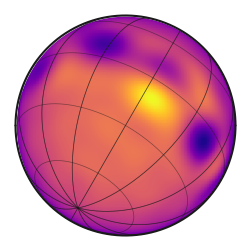

In [48]:
map.show()

In [10]:
t.shape

(64801,)

In [26]:
sys.show(t[::10])

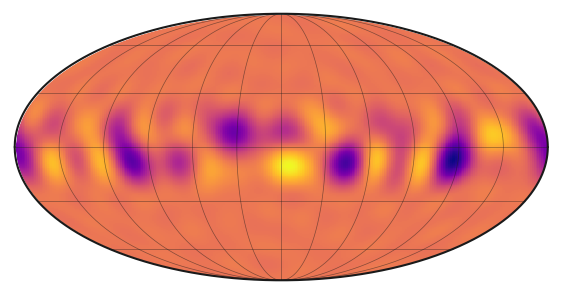

In [49]:
map.show(projection='moll')

In [50]:
K00 = 0.
K01 = 10.
K10 = np.log(0.5)
K11 = 10.
alpha = np.exp(K00 + (K10 - K00) * params['gp.a']['truth'])
beta = np.exp(K10 + (K11 - K10) * params['gp.b']['truth']) 

sp_mu = alpha / (alpha + beta) * 180 / np.pi 
sp_var = alpha * beta / (np.square(alpha + beta) * (alpha + beta + 1)) * 180 / np.pi

In [51]:
theta = (360 * t / params["star.prot"]['truth']) % 360
xo, yo, zo = sys.position(t)
xo = xo.eval()[1]
yo = yo.eval()[1]
zo = zo.eval()[1]
A = map.design_matrix(
    theta=theta, xo=xo, yo=yo, zo=zo, ro=params["planet.r"]['truth']
).eval()

In [52]:
rng = np.random.default_rng(9878997)
flux_true = A @ y_true
sigma_flux = 1e-4*np.ones_like(flux_true)
flux_obs = flux_true + sigma_flux*rng.normal(size=len(t))

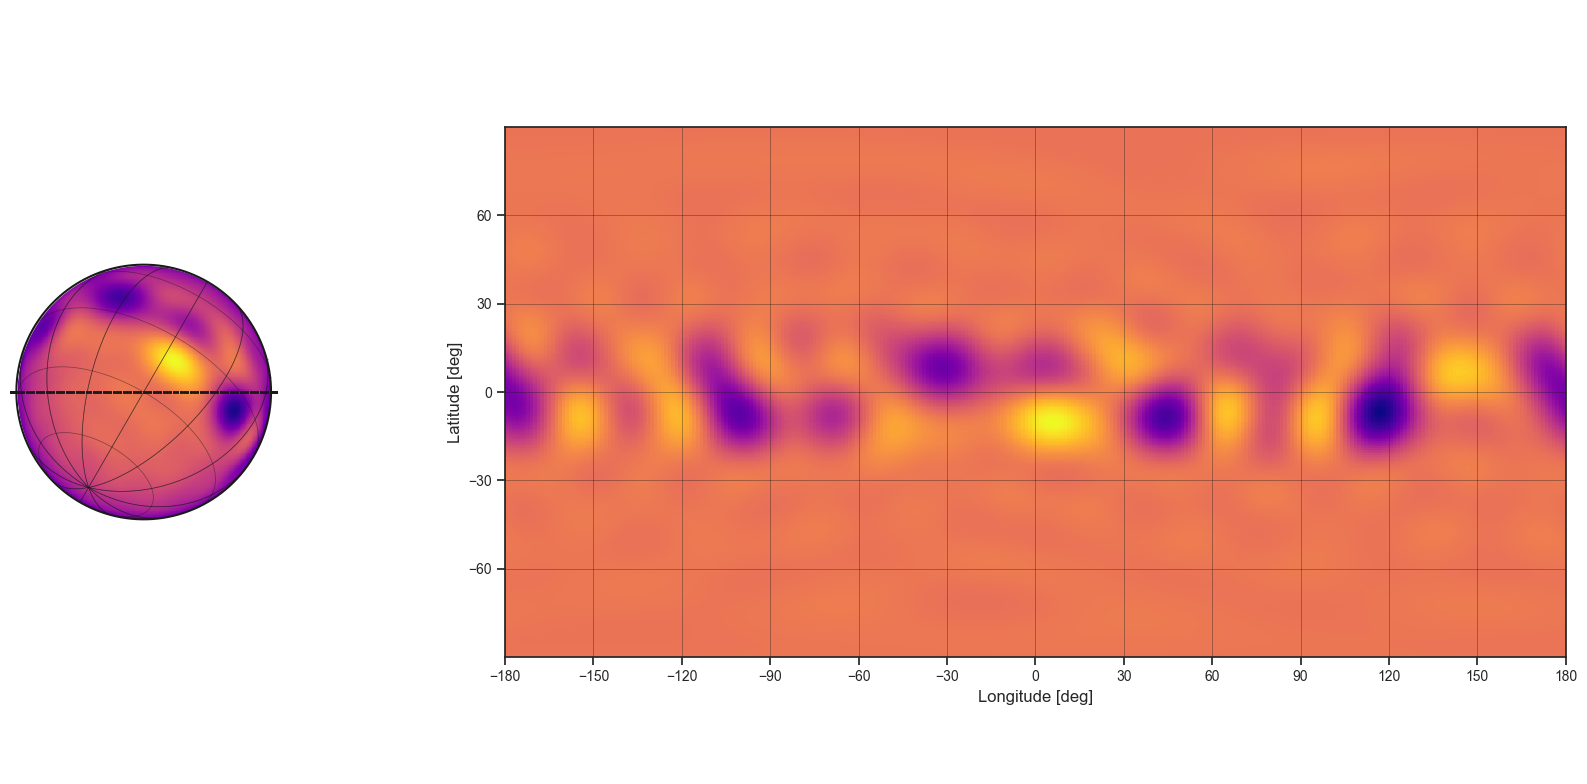

In [53]:
fig, ax = plt.subplots(1, 2, figsize=(20, 8))
idx = (zo > 0) | (xo ** 2 + yo ** 2 > 1)
ax[0].plot(xo[idx], yo[idx], "k.", ms=1);
ax[0].set_aspect(1)
ax[0].axis("off")
map[:, :] = y_true
map.show(ax=ax[0])
ax[0].set_ylim(-3, 3)
idx = (zo > 0) & (xo ** 2 + yo ** 2 < 1)
lat = 180 / np.pi * np.arcsin(yo[idx])
lon = 180 / np.pi * np.arcsin(xo[idx] / np.sqrt(1 - yo[idx] ** 2)) - theta[idx]
lon = (lon + 180) % 360 - 180
mask = np.append(np.array(lon[1:] > lon[:-1], dtype=float), 0)
mask[mask == 1] = np.nan
map.show(ax=ax[1], projection="rect")
ax[1].plot(lon, lat + mask, "k-");
plt.tight_layout()
plt.savefig("figures/experiment-1-true-map.pdf", bbox_inches="tight", dpi=300)

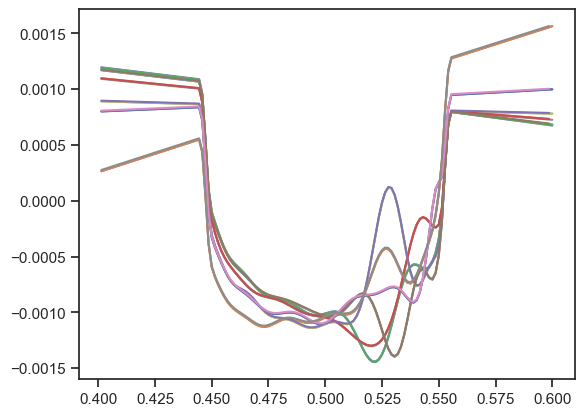

In [54]:
ntransits = int(np.ceil(t[-1] / planet.porb.eval()))
fig, ax = plt.subplots(1, 1)
for n in range(ntransits):
    idx = (t > planet.t0.eval()+n*planet.porb.eval()-0.1) &  (t<planet.t0.eval()+n*planet.porb.eval()+0.1)
    plt.plot(t[idx] % planet.porb.eval(), flux_true[idx] - np.mean(flux_true[idx]))

In [55]:
t_, flux_, sigma_flux_ = bin_out_of_transit(t, flux_obs, sigma_flux, params, binsize=100)

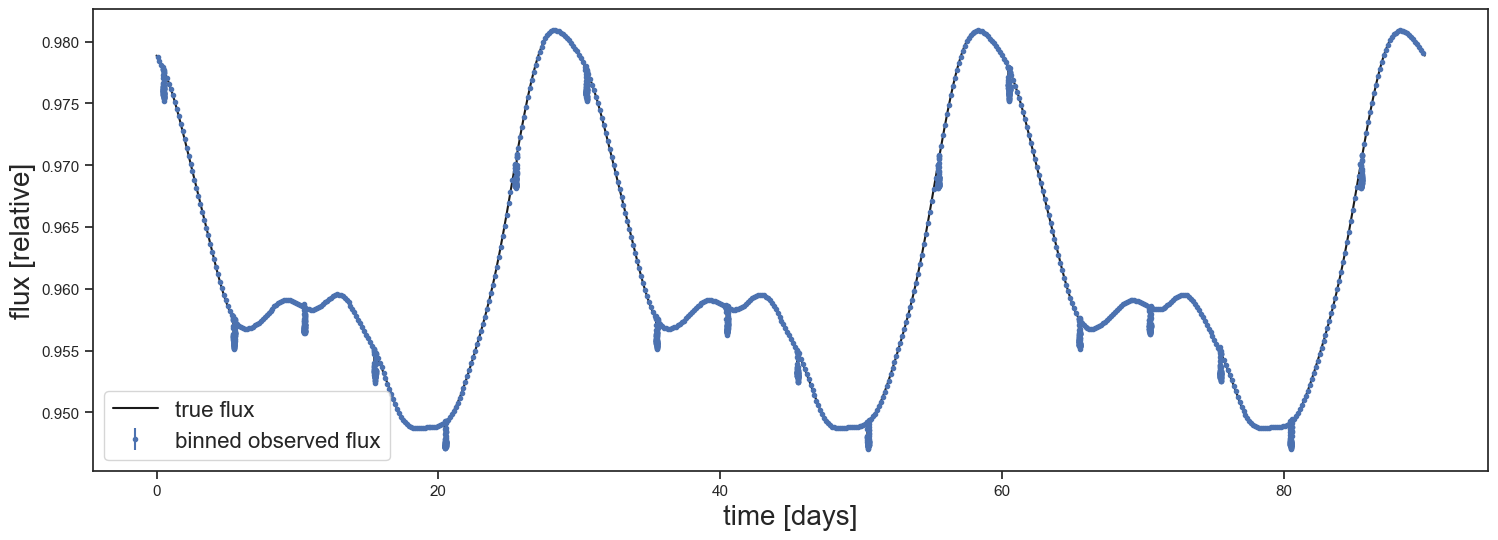

In [56]:
plt.figure(figsize=(18,6))
plt.plot(t, flux_true, color='k', label='true flux')
plt.errorbar(t_, flux_, yerr=sigma_flux_, fmt='.', color='C0', label='binned observed flux')
plt.ylabel("flux [relative]", fontsize=20)
plt.xlabel("time [days]", fontsize=20)
plt.legend(fontsize=16);
plt.savefig("figures/experiment-1-lc.pdf", bbox_inches="tight", dpi=300)
# plt.xlim(0,20)

(15.0, 16.0)

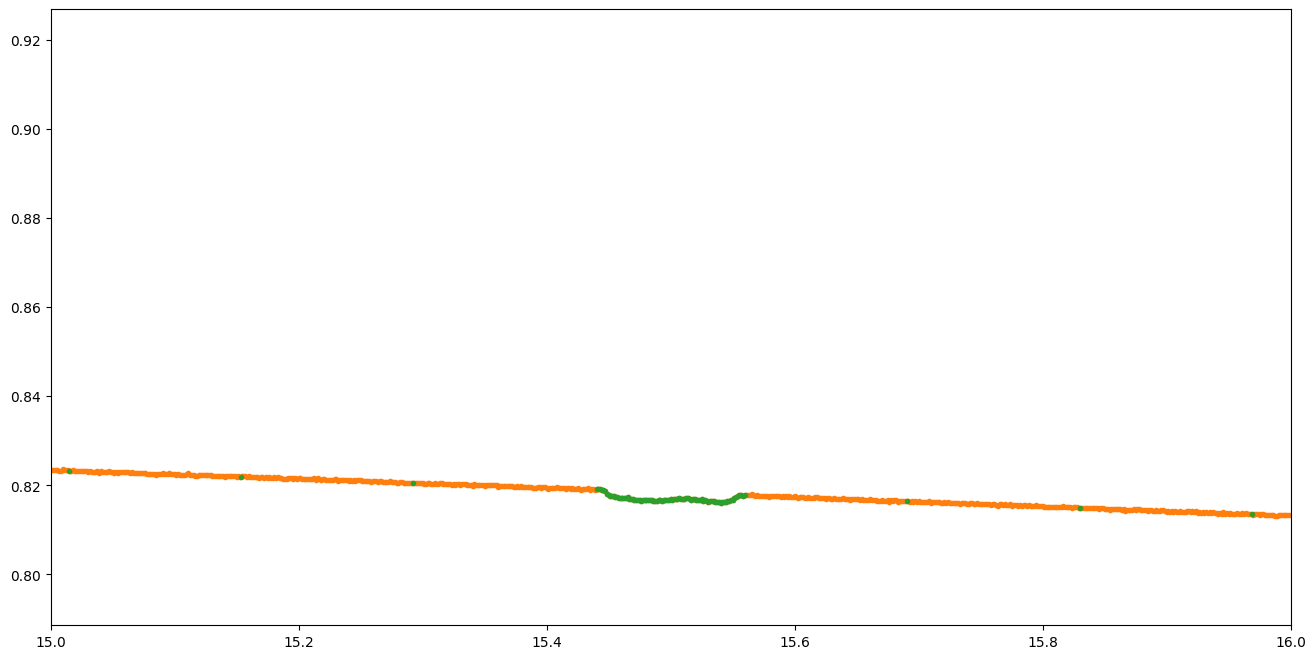

In [20]:
plt.figure(figsize=(16,8))
plt.plot(t, flux_true)
plt.plot(t, flux_obs, '.')
plt.plot(t_, flux_, '.')
plt.xlim(15, 16)

In [21]:
np.sum(np.isnan(flux_))

0

In [22]:
# Set some free params & get the model
p = dict(params)

p['planet.porb']['free'] = True
p['planet.t0']['free'] = True
p['planet.r']['free'] = True
p['planet.inc']['free'] = True
p['planet.ecc']['free'] = True

p['star.u1']['free'] = True
p['star.u2']['free'] = True

p['gp.c']['free'] = True
p['gp.a']['free'] = True
p['gp.b']['free'] = True
p['gp.r']['free'] = True
p['gp.n']['free'] = True

p['star.prot']['free'] = True
p['star.obl']['free'] = True
p['star.inc']['free'] = True

free = [x for x in p.keys() if p[x].get("free", False)]
model = gp_model(t_, flux_, sigma_flux_, p)

In [58]:
params['sp.mu'] = {'truth': sp_mu, 'dist': None, 'args': None}
params['sp.var'] = {'truth': sp_var, 'dist': None, 'args': None}

replacements = {'gp.a': 'sp.mu', 'gp.b': 'sp.var'}
free = [replacements.get(item, item) for item in free]

In [32]:
with model:
    map_soln = pmx.optimize()
    for x in free:
        print(f"{x}: {map_soln[x]} {[params[x]['truth']]}")

optimizing logp for variables: [gp.n, gp.r, gp.c, gp.b, gp.a, star.u2, star.u1, stellar_ori_z_, stellar_ori_y_, stellar_ori_x_, planet.ecc, b, planet.rlog, planet.t0, planet.porblogp, star.protlogp]



planet.inc: 89.06508360086806 [90.0]
planet.ecc: 0.21228093377170368 [0.2]
planet.porb: 5.000002721263177 [5.0]
planet.t0: 0.5000285760835296 [0.5]
planet.r: 0.041885915800715344 [0.04]
star.inc: 98.57628551574632 [120]
star.u1: 0.33265725311250327 [0.4]
star.u2: 0.28452696837815494 [0.26]
star.prot: 30.00000593436046 [30.0]
star.obl: 33.008945576855915 [-30]
gp.a: 0.2928629875480867 [0.6]
gp.b: 0.22571416100248903 [0.2]
gp.r: 10.25495223221341 [20]
gp.c: 0.5459495261460148 [0.5]
gp.n: 6.5223726688664385 [3]


message: Desired error not necessarily achieved due to precision loss.
logp: -47467161.992892325 -> 18051.708193681607


In [37]:
with model:
    map_soln = pmx.optimize(start=map_soln)
    for x in free:
        print(f"{x}: {map_soln[x]} {[params[x]['truth']]}")

optimizing logp for variables: [gp.n, gp.r, gp.c, gp.b, gp.a, star.u2, star.u1, stellar_ori_z_, stellar_ori_y_, stellar_ori_x_, planet.ecc, b, planet.rlog, planet.t0, planet.porblogp, star.protlogp]



planet.inc: 89.06508360086806 [90.0]
planet.ecc: 0.21228093377170368 [0.2]
planet.porb: 5.000002721263177 [5.0]
planet.t0: 0.5000285760835296 [0.5]
planet.r: 0.041885915800715344 [0.04]
star.inc: 98.57628551574632 [120]
star.u1: 0.33265725311250327 [0.4]
star.u2: 0.28452696837815494 [0.26]
star.prot: 30.00000593436046 [30.0]
star.obl: 33.008945576855915 [-30]
gp.a: 0.2928629875480867 [0.6]
gp.b: 0.22571416100248903 [0.2]
gp.r: 10.25495223221341 [20]
gp.c: 0.5459495261460148 [0.5]
gp.n: 6.5223726688664385 [3]


message: Desired error not necessarily achieved due to precision loss.
logp: 18051.708193681607 -> 18051.708193681607


In [38]:
best_params = {}
best_params['star.inc'] = params['star.inc']['truth']
best_params['star.obl'] = params['star.obl']['truth']
best_params['gp.a'] = params['gp.a']['truth']
best_params['gp.b'] = params['gp.b']['truth']
best_params['gp.c'] = params['gp.c']['truth']
best_params['gp.n'] = params['gp.n']['truth']
best_params['gp.r'] = params['gp.r']['truth']
best_params['star.prot'] = params['star.prot']['truth']
best_params['planet.porb'] = params['planet.porb']['truth']
best_params['planet.t0'] = params['planet.t0']['truth']
best_params['planet.ecc'] = params['planet.ecc']['truth']
best_params['star.u1'] = params['star.u1']['truth']
best_params['star.u2'] = params['star.u2']['truth']
best_params['planet.inc'] = params['planet.inc']['truth']

In [39]:
with model:
    map_soln = pmx.optimize(start=best_params)
    for x in free:
        print(f"{x}: {map_soln[x]} {[params[x]['truth']]}")

optimizing logp for variables: [gp.n, gp.r, gp.c, gp.b, gp.a, star.u2, star.u1, stellar_ori_z_, stellar_ori_y_, stellar_ori_x_, planet.ecc, b, planet.rlog, planet.t0, planet.porblogp, star.protlogp]



planet.inc: 89.06508360086806 [90.0]
planet.ecc: 0.21228093377170368 [0.2]
planet.porb: 5.000002721263177 [5.0]
planet.t0: 0.5000285760835296 [0.5]
planet.r: 0.041885915800715344 [0.04]
star.inc: 98.57628551574632 [120]
star.u1: 0.33265725311250327 [0.4]
star.u2: 0.28452696837815494 [0.26]
star.prot: 30.00000593436046 [30.0]
star.obl: 33.008945576855915 [-30]
gp.a: 0.2928629875480867 [0.6]
gp.b: 0.22571416100248903 [0.2]
gp.r: 10.25495223221341 [20]
gp.c: 0.5459495261460148 [0.5]
gp.n: 6.5223726688664385 [3]


message: Desired error not necessarily achieved due to precision loss.
logp: -47467161.992892325 -> 18051.708193681607


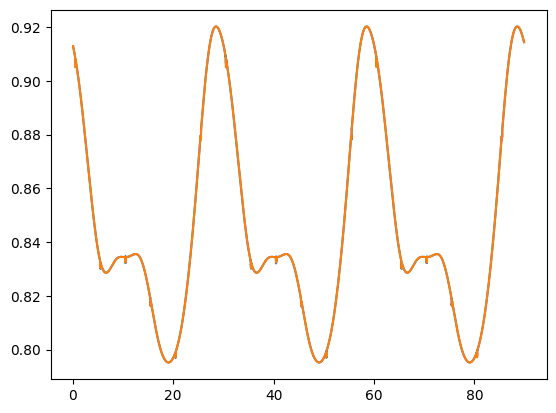

In [40]:
plt.plot(t_, flux_)
plt.plot(t_, map_soln['flux_model'])
# plt.xlim(15,16)

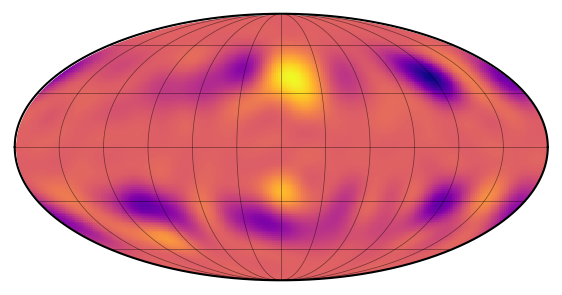

In [41]:
sp.visualize(map_soln['max_map'])

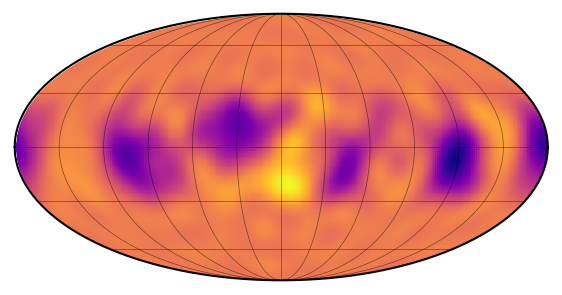

In [42]:
sp.visualize(y_true)

In [43]:
with model:
    trace = pmx.sample(
        tune=1000,
        draws=1000,
        start=map_soln,
        chains=1,
        cores=4,
        target_accept=0.9,
        return_inferencedata=False,
    )

The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
Sequential sampling (1 chains in 1 job)
NUTS: [gp.n, gp.r, gp.c, gp.b, gp.a, star.u2, star.u1, stellar_ori_z_, stellar_ori_y_, stellar_ori_x_, planet.ecc, b, planet.rlog, planet.t0, planet.porblogp, star.protlogp]


Sampling 1 chain for 1_000 tune and 1_000 draw iterations (1_000 + 1_000 draws total) took 36058 seconds.
There were 40 divergences after tuning. Increase `target_accept` or reparameterize.
Only one chain was sampled, this makes it impossible to run some convergence checks


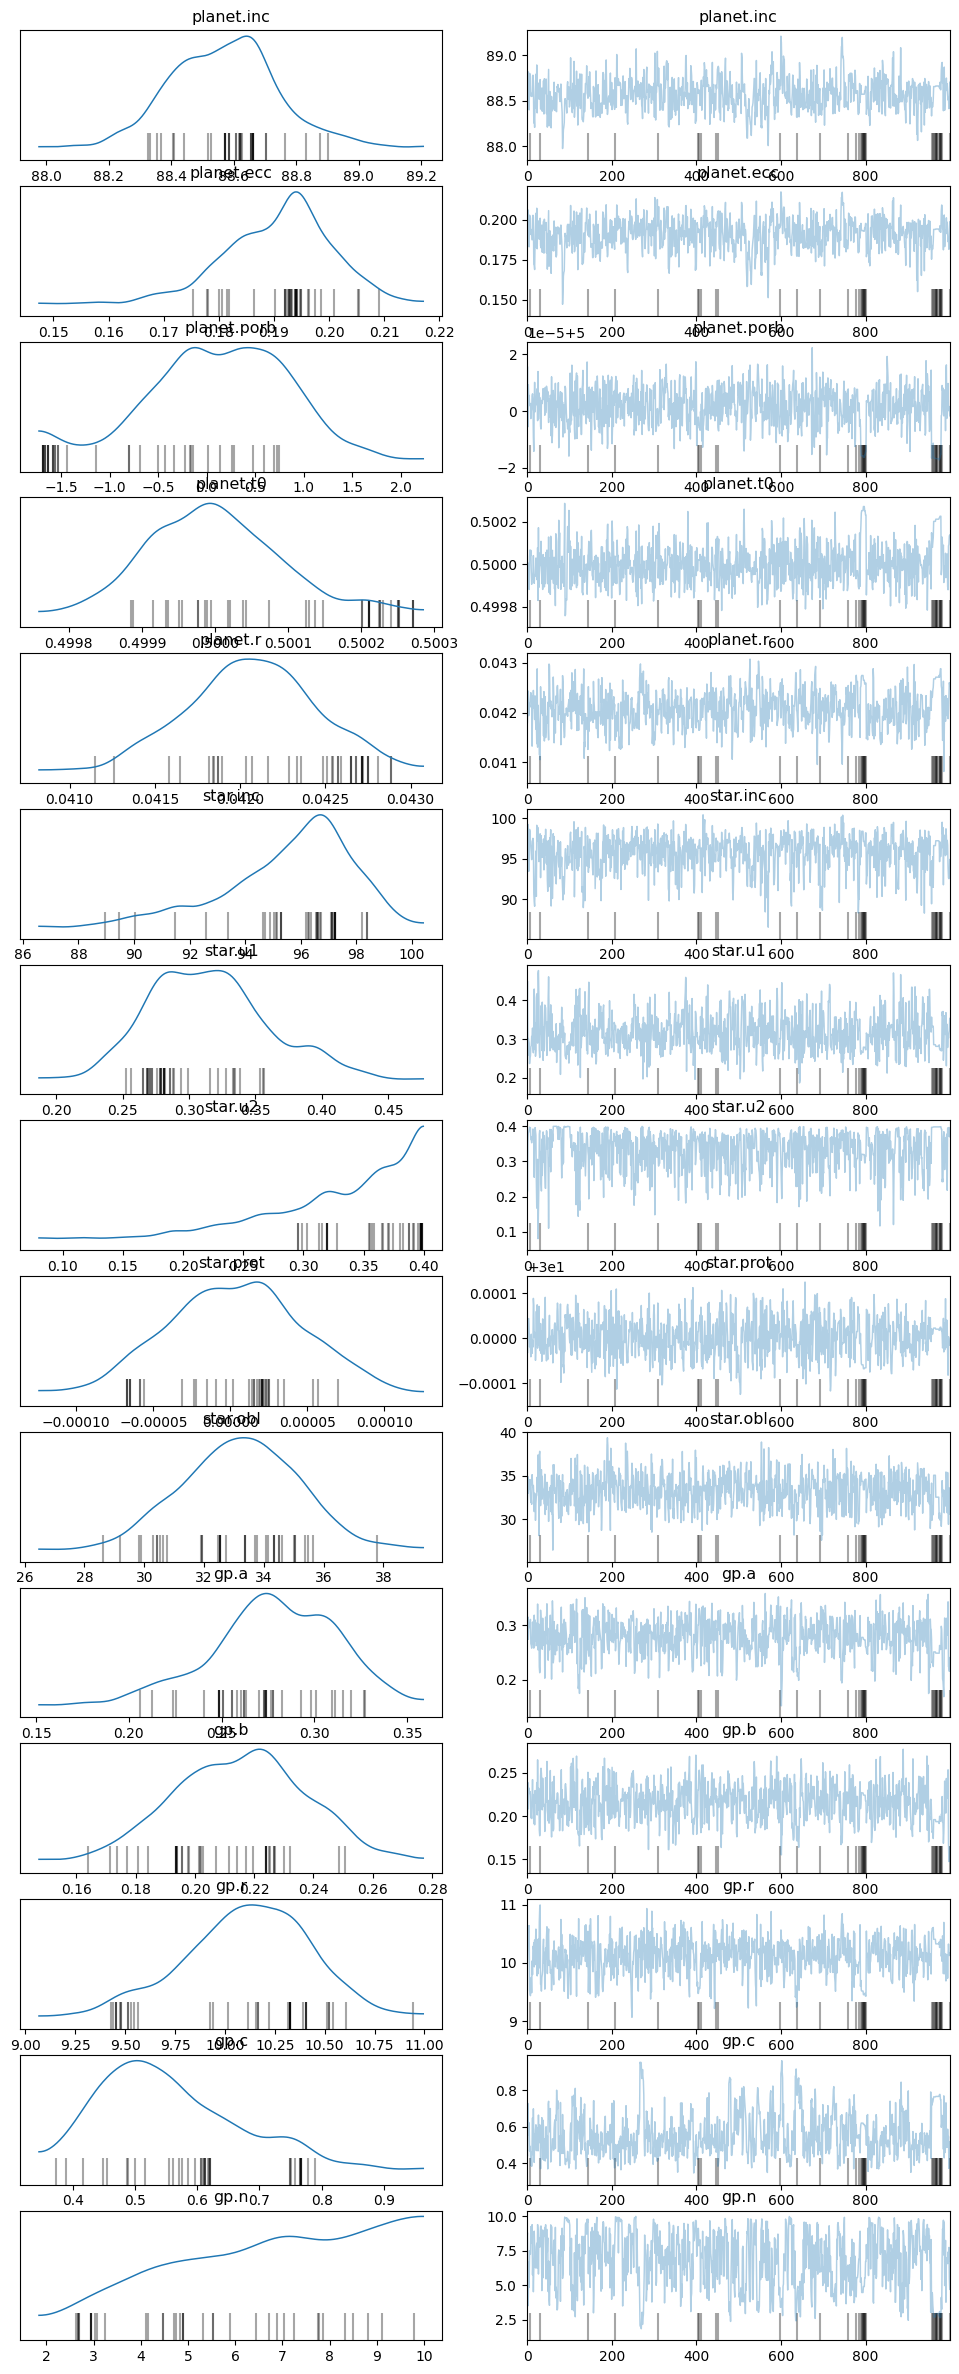

In [44]:
with model:
    az.plot_trace(trace, var_names=free)

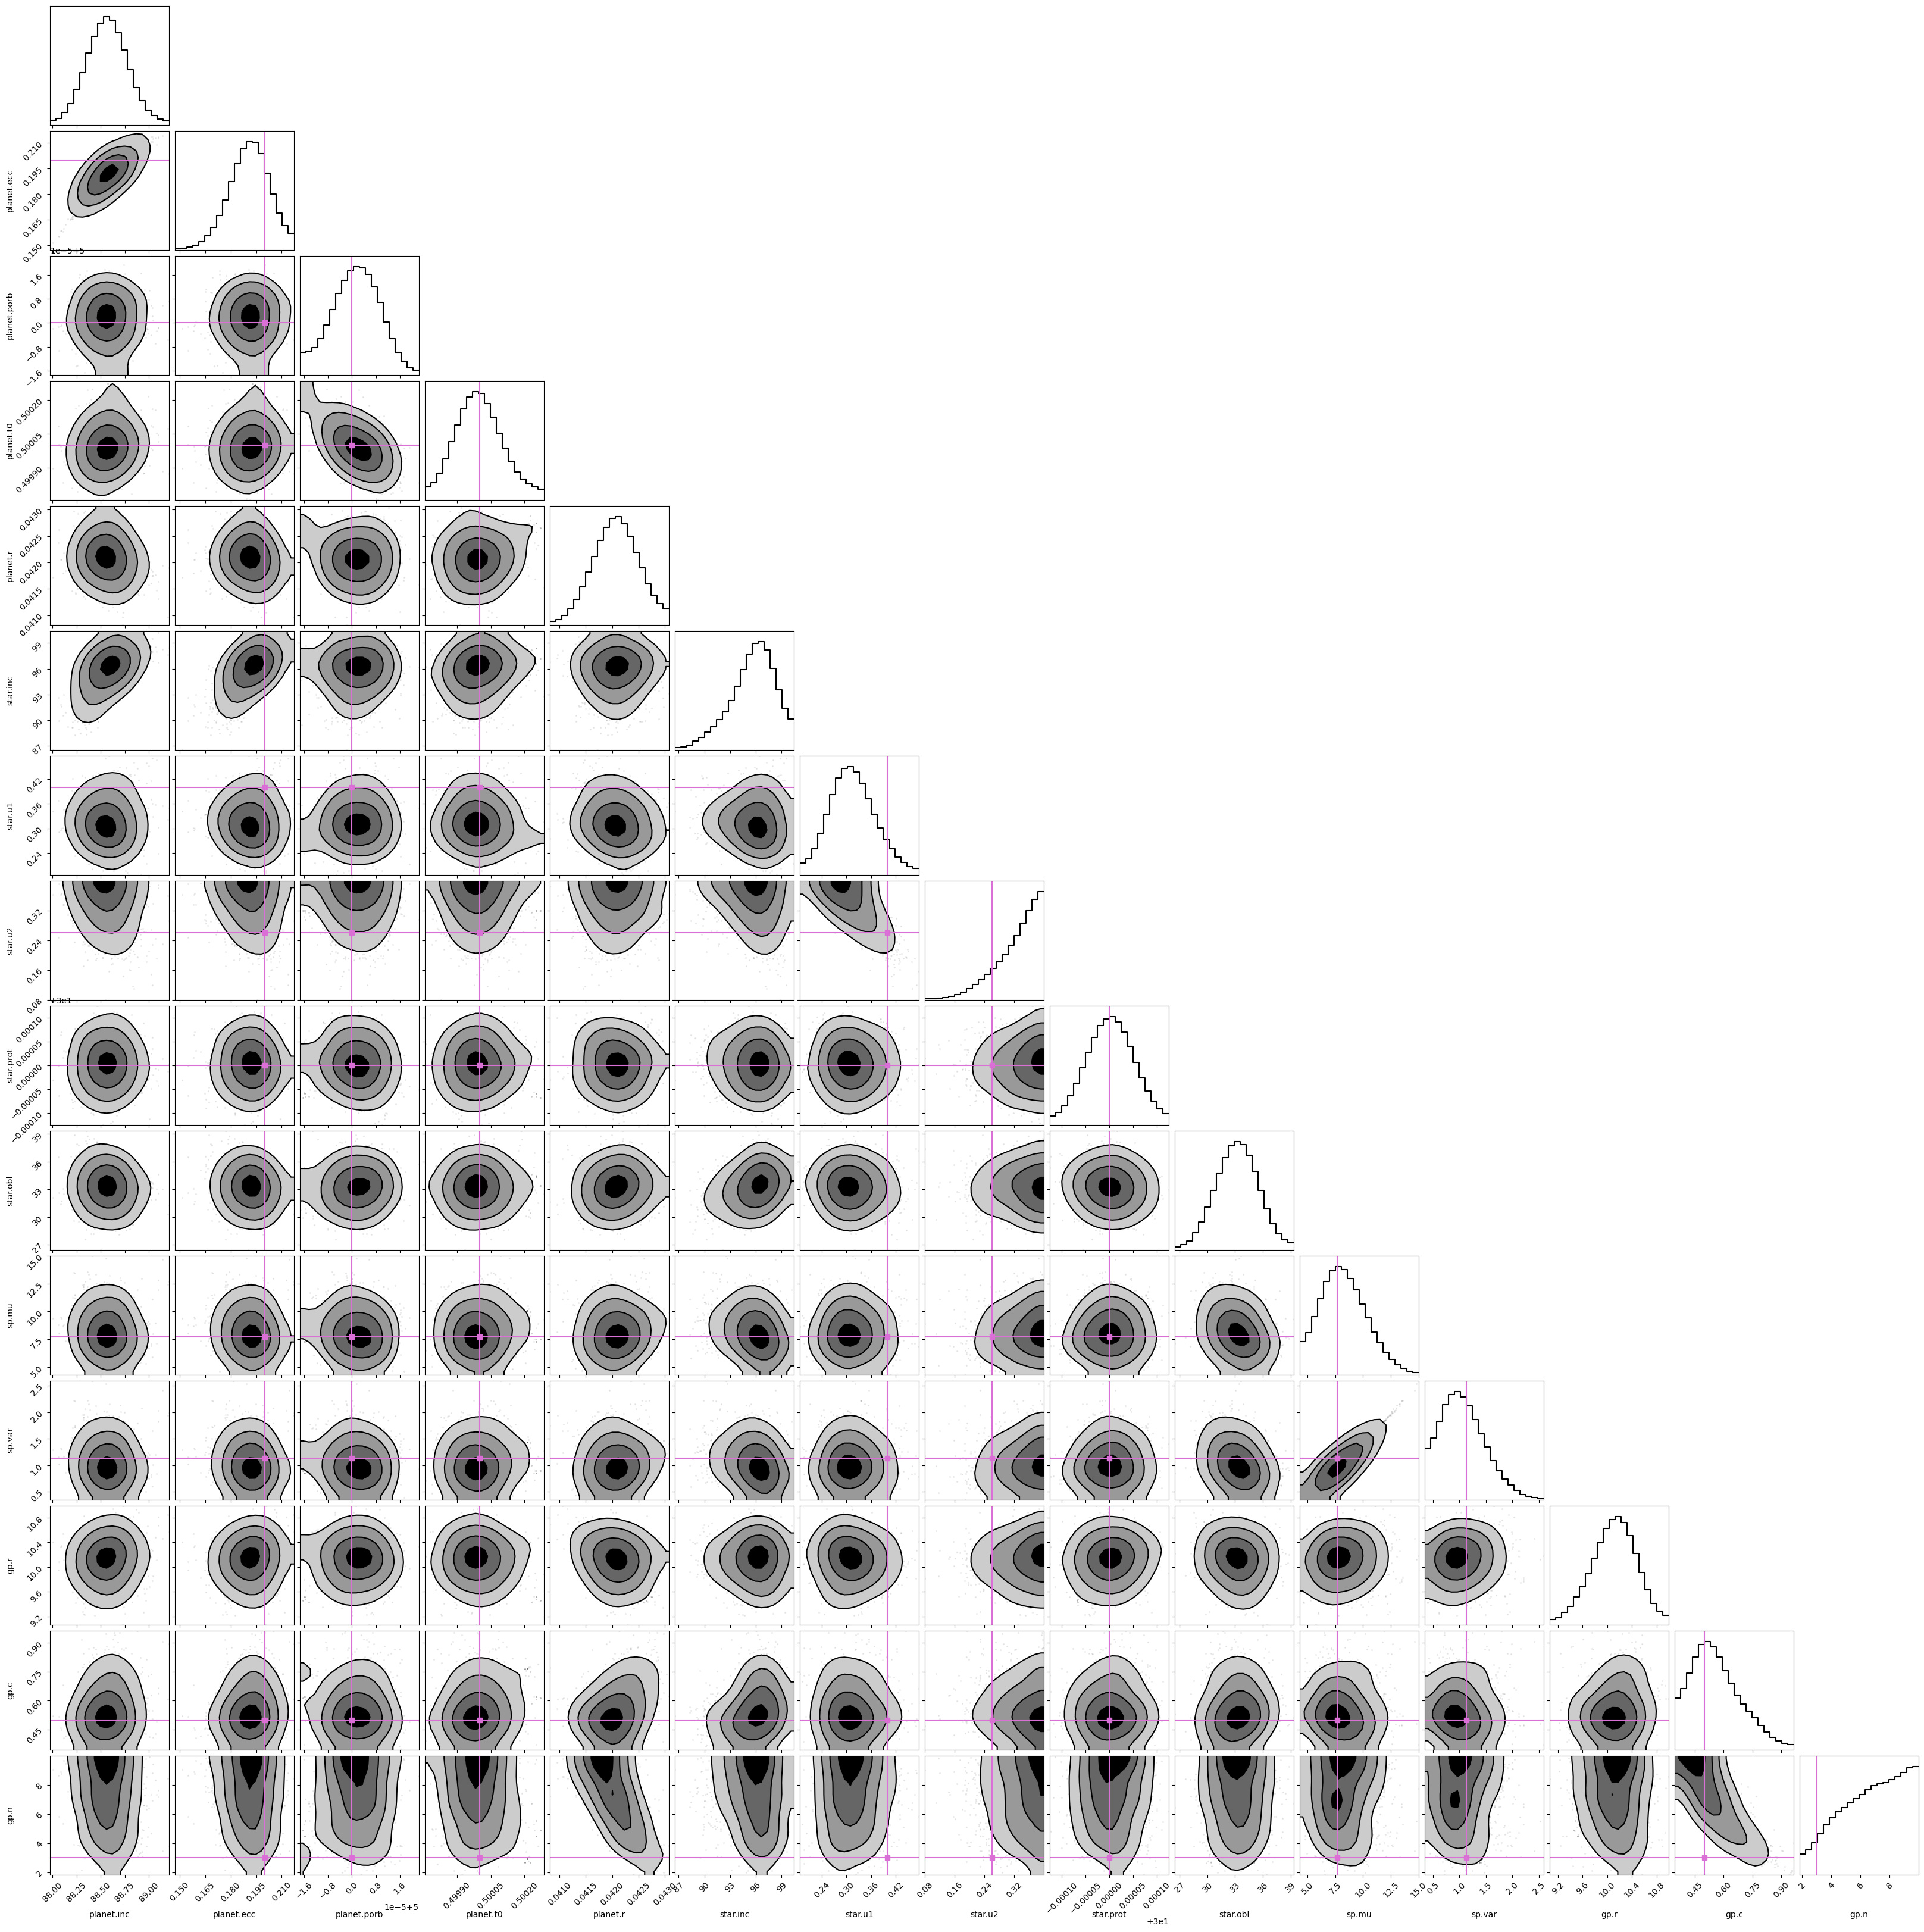

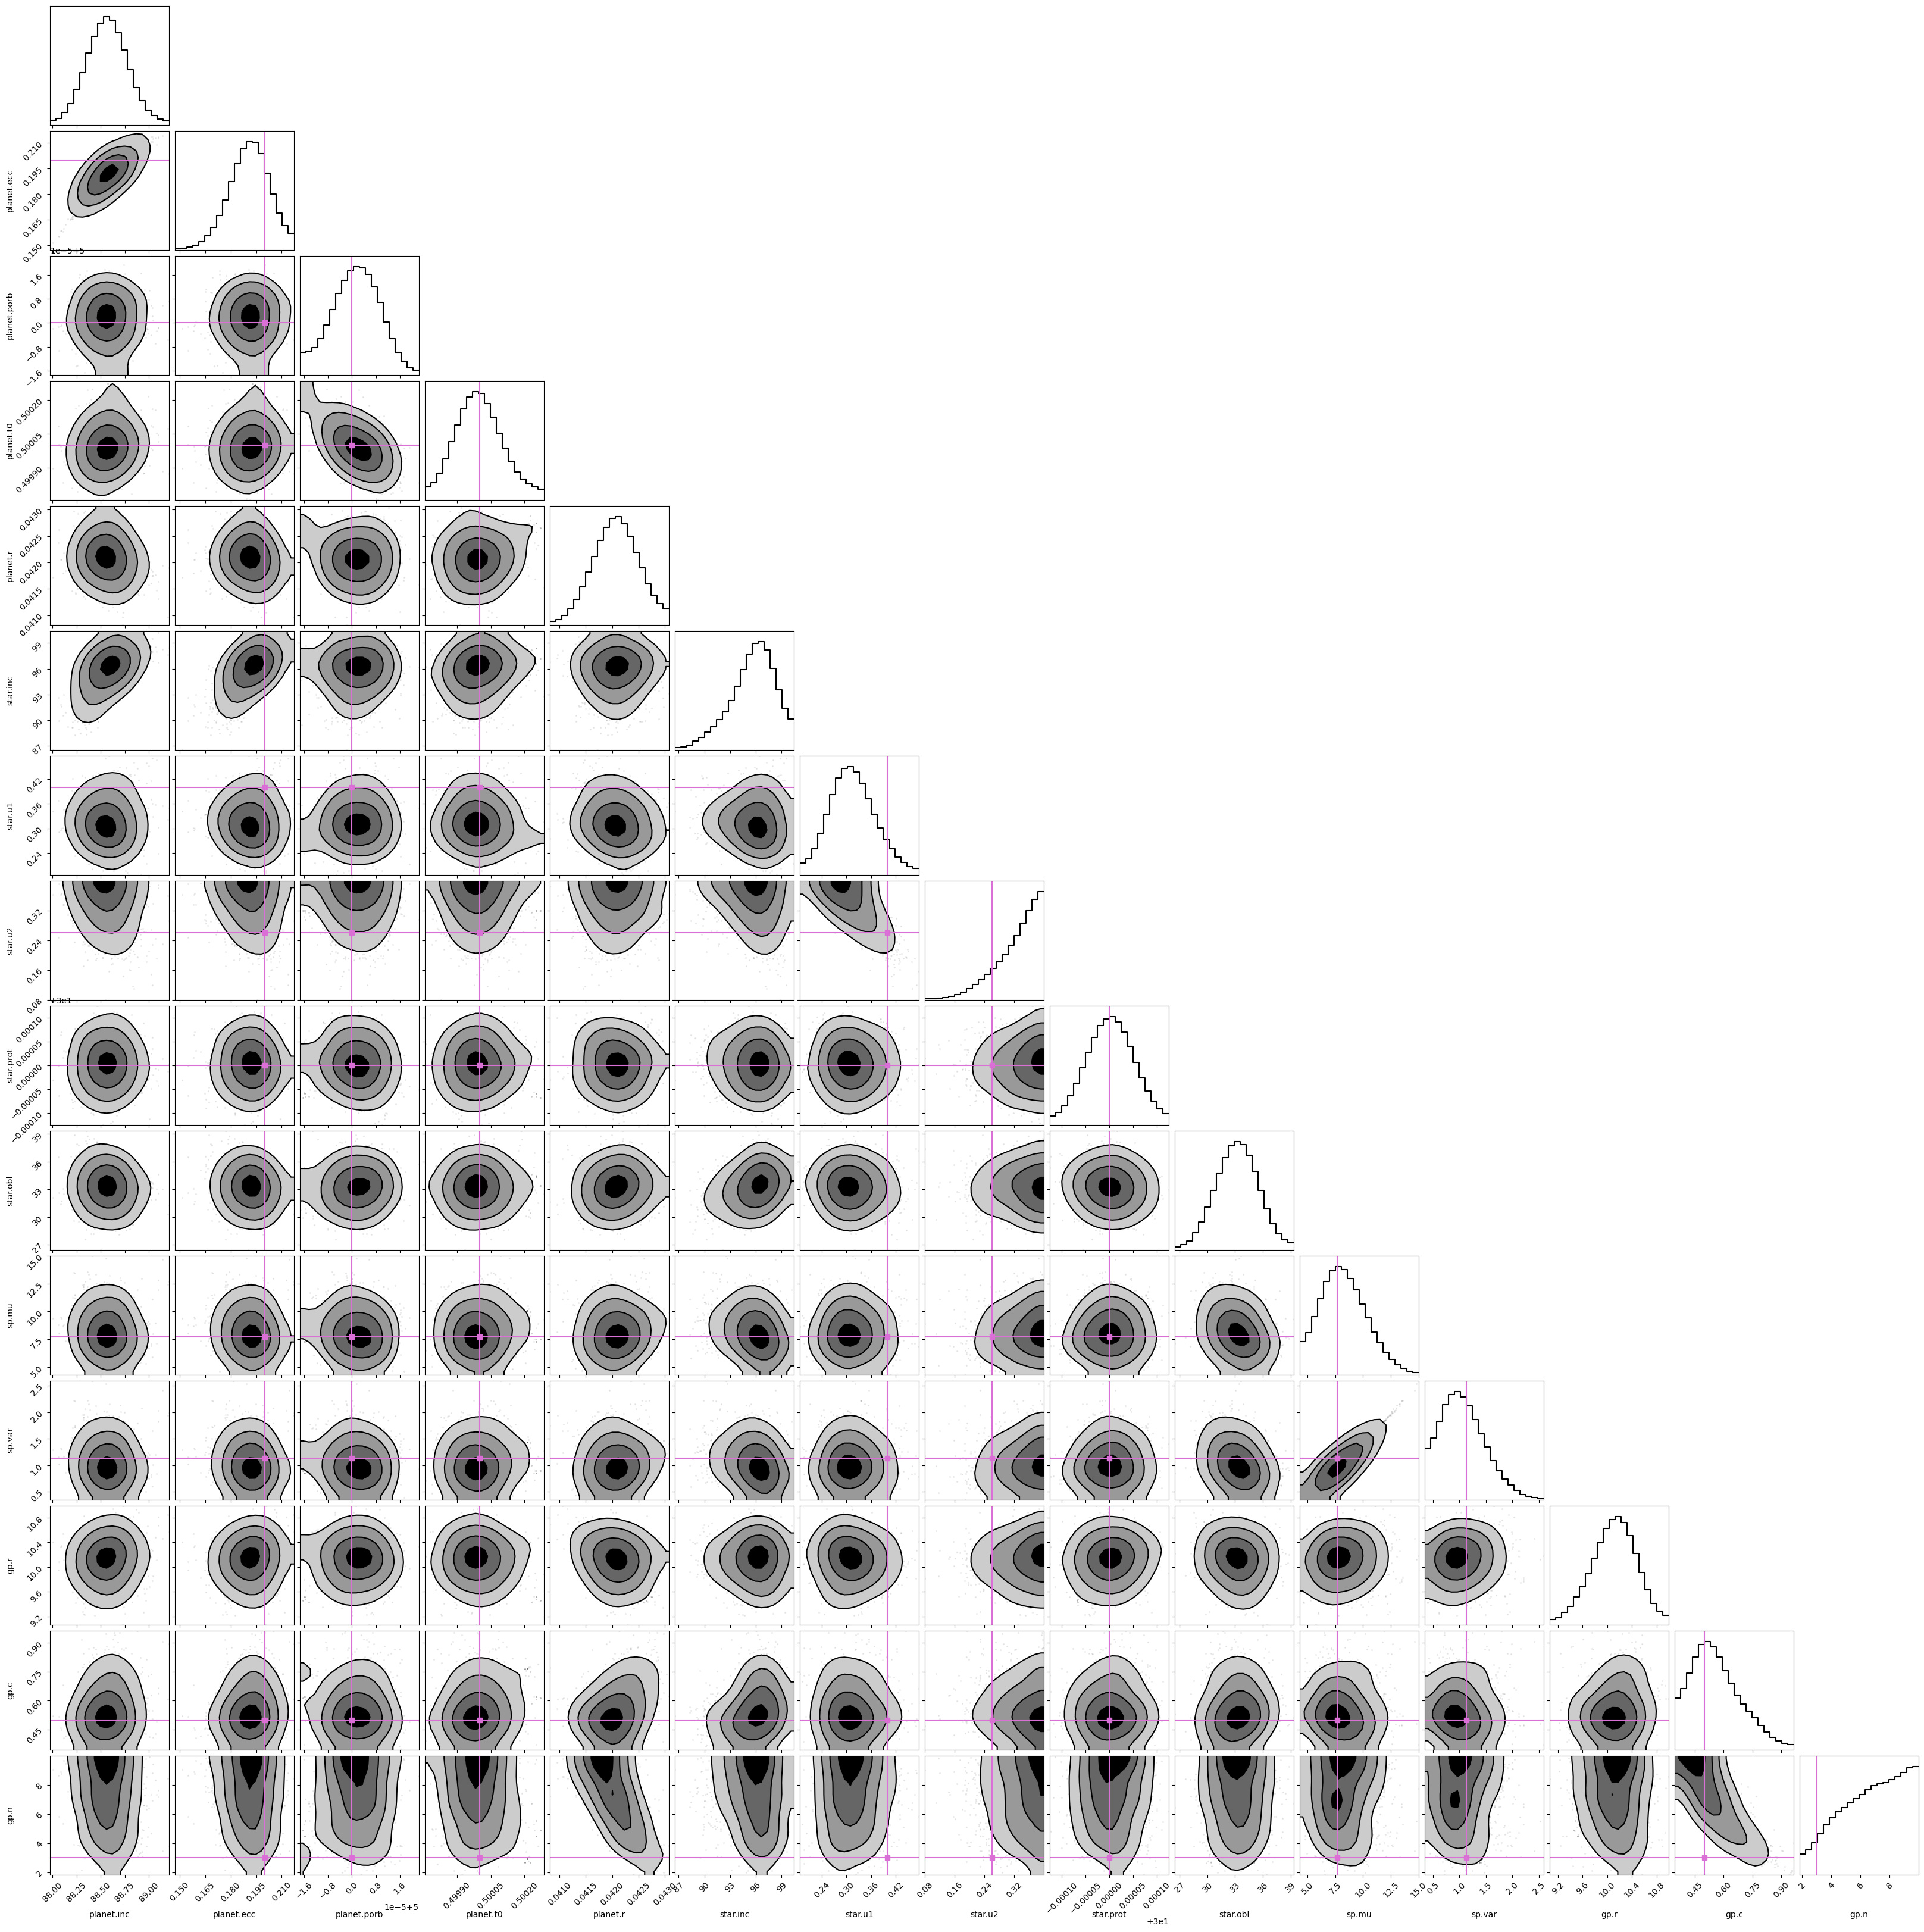

In [75]:
samples = pm.trace_to_dataframe(trace,varnames=free)
corner(np.array(samples), labels=free,
        truths=[params[x]['truth'] for x in free], 
        color='k', 
        truth_color='orchid',
        plot_datapoints=True,
        plot_density=False,
        fill_contours=True,
        smooth=2.,
        smooth1d=2.,
        hist_kwargs=dict(alpha=1))

In [46]:
az.to_netcdf(trace,'SSP-experiment-1-all.nc')

Got error No model on context stack. trying to find log_likelihood in translation.


'SSP-experiment-1-all.nc'

In [24]:
samples_fromfile = az.from_netcdf('SSP-experiment-1-all.nc')

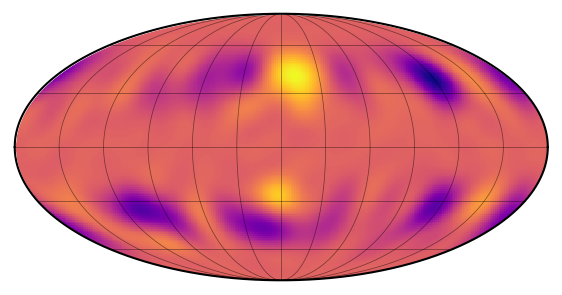

In [25]:
sp.visualize(np.mean(samples_fromfile.posterior[f'max_map'][0].values, axis=0))

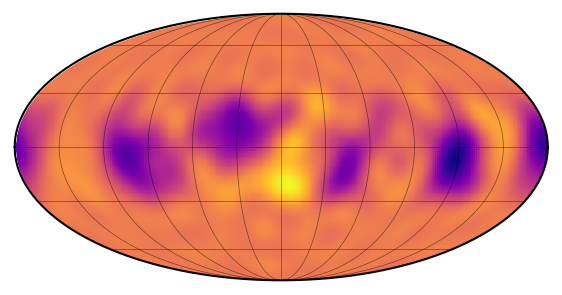

In [26]:
sp.visualize(y_true)

array([[<Axes: ylabel='sp.mu'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='sp.var'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='gp.r'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='gp.c'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: xlabel='sp.mu', ylabel='gp.n'>, <Axes: xlabel='sp.var'>,
        <Axes: xlabel='gp.r'>, <Axes: xlabel='gp.c'>,
        <Axes: xlabel='gp.n'>]], dtype=object)

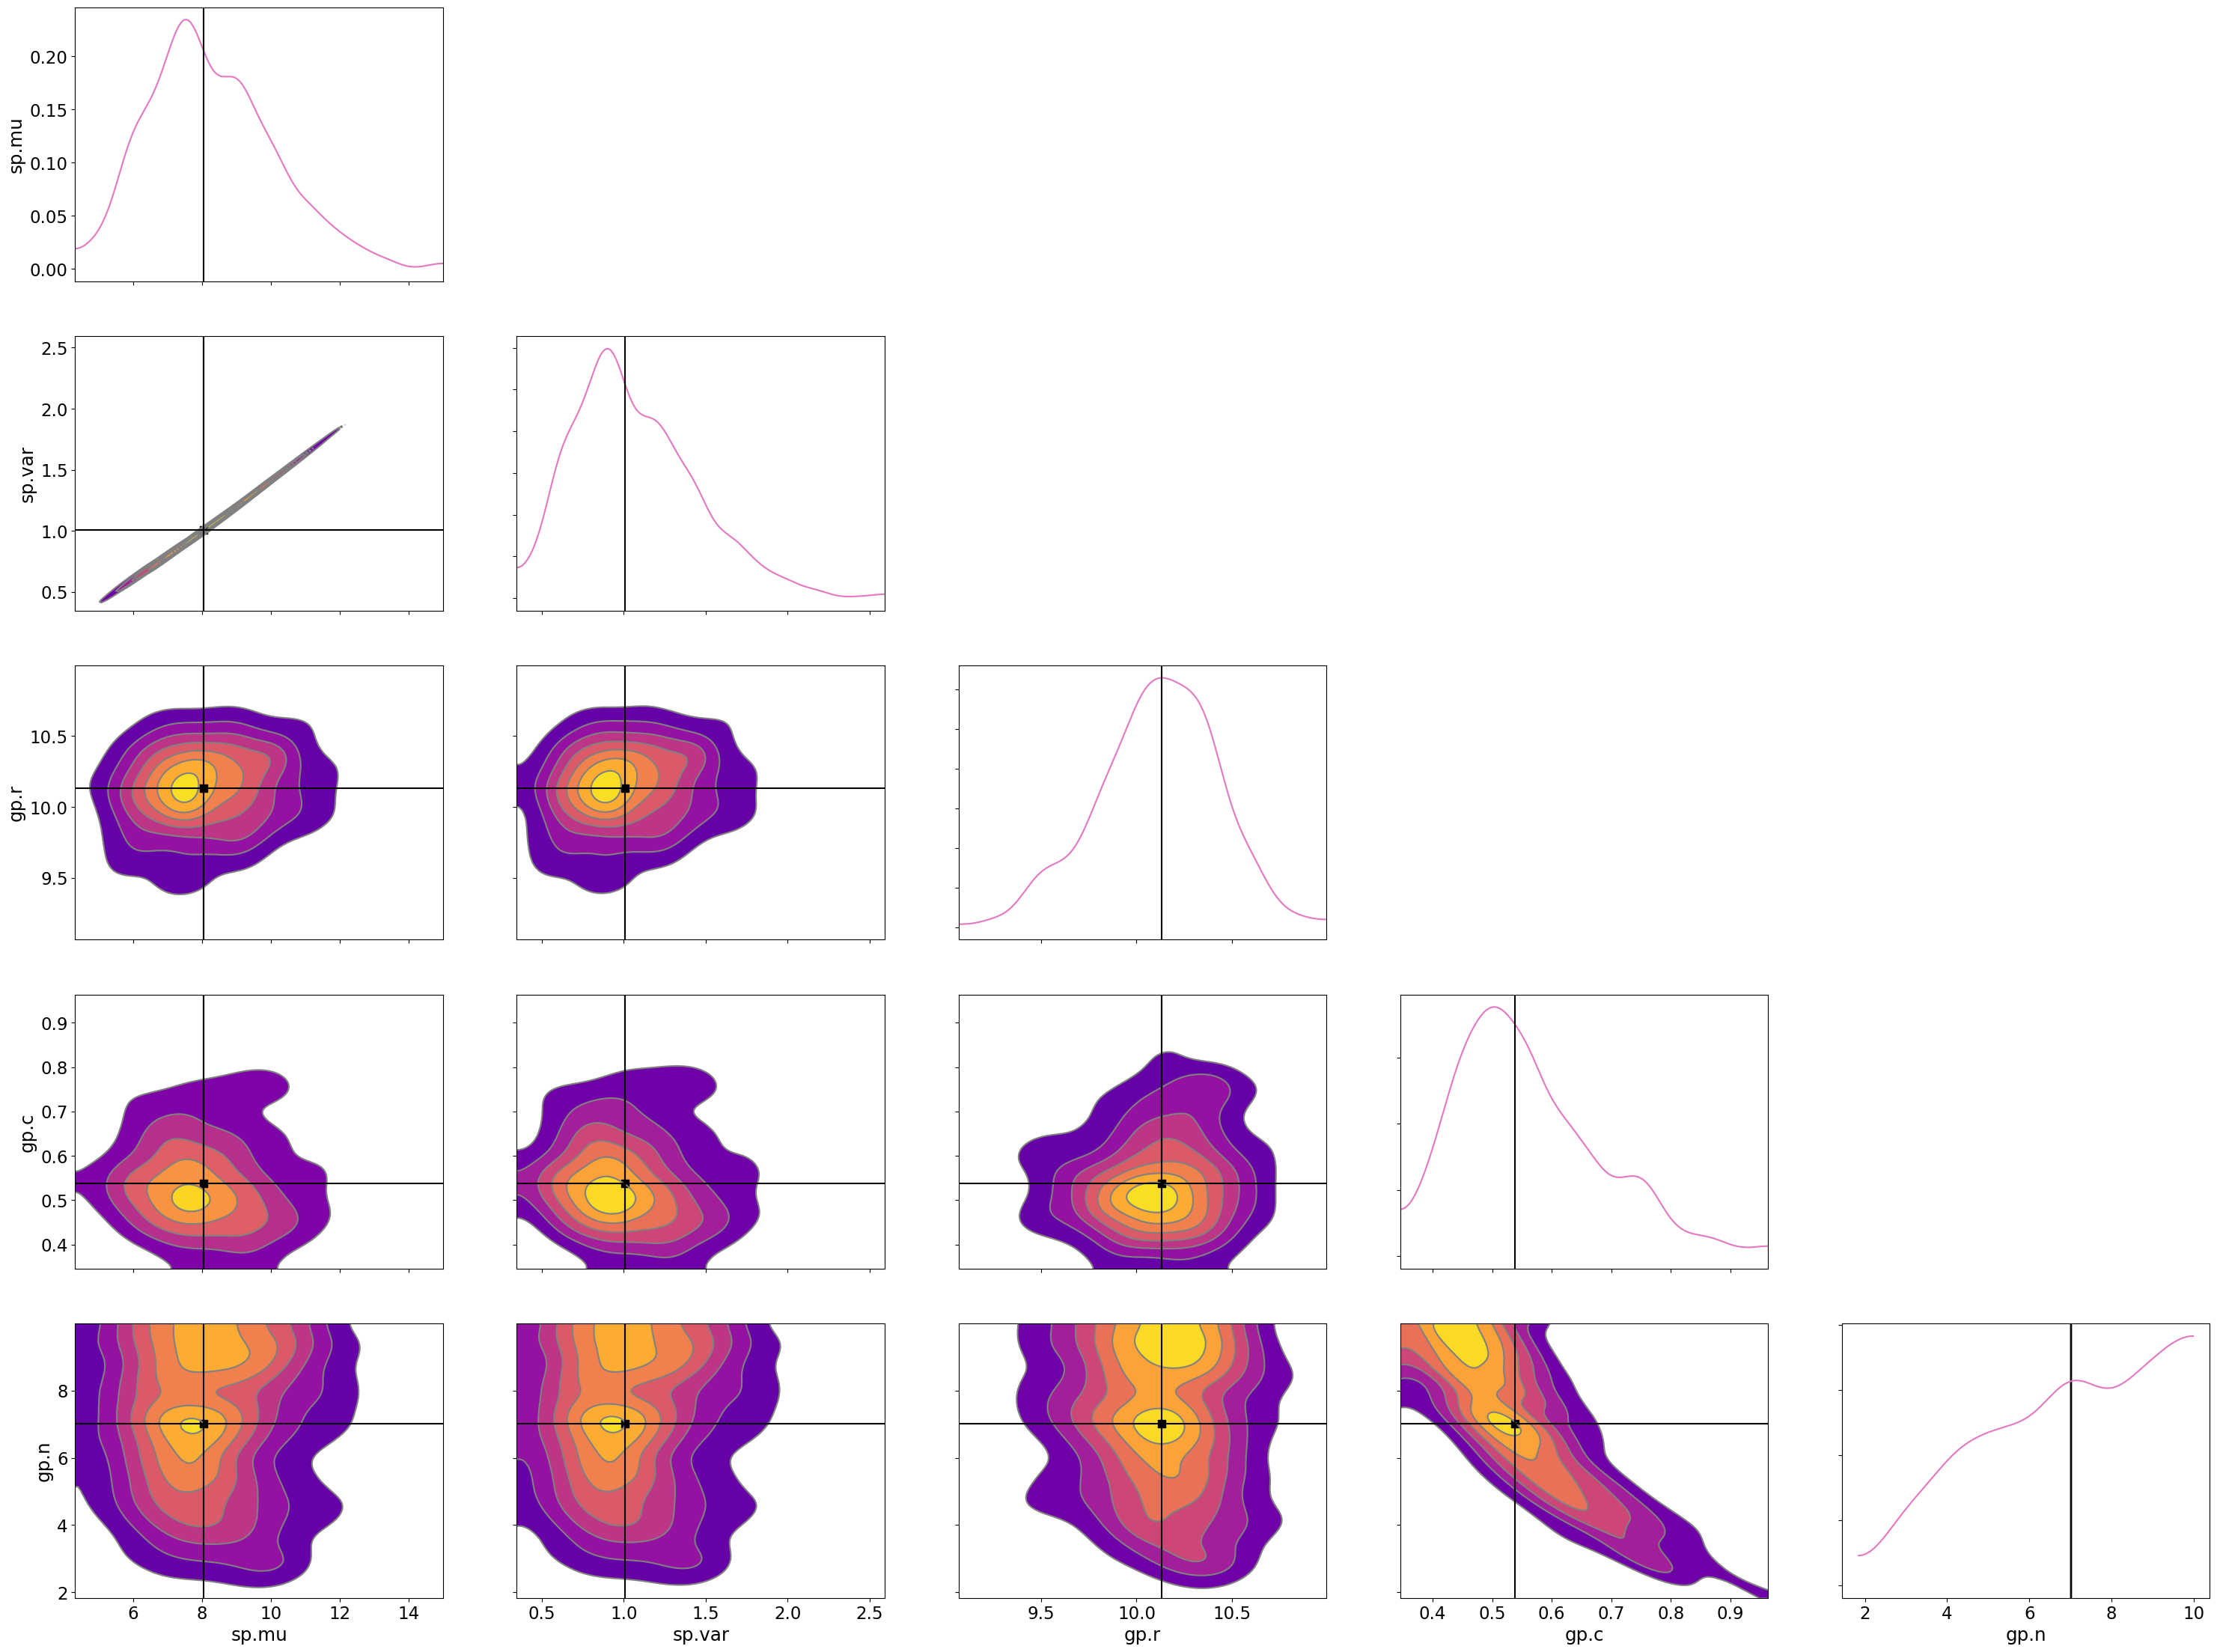

In [51]:
az.plot_pair(
    samples_fromfile.posterior, 
    var_names=['sp.mu', 'sp.var', 'gp.r', 'gp.c', 'gp.n'], 
    kind='kde', 
    marginals=True, 
    textsize=16.5, 
    kde_kwargs={'contourf_kwargs':{'color':'C6','cmap':plt.cm.plasma}, 'fill_kwargs':{'alpha': 0.5}},
    divergences=True,
    marginal_kwargs={'color': "C6"},
    point_estimate='median'
    )

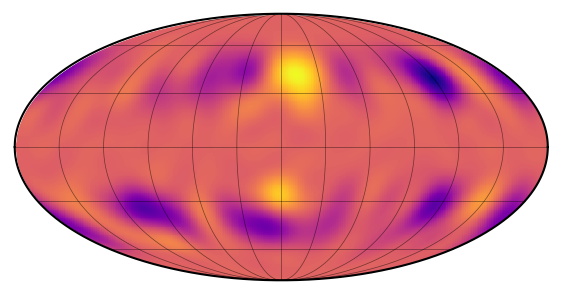

In [58]:
map_inf = starry.Map(15,2)
map_inf[:,:] = np.mean(samples_fromfile.posterior[f'max_map'][0].values, axis=0)
map_inf.show(projection='moll')

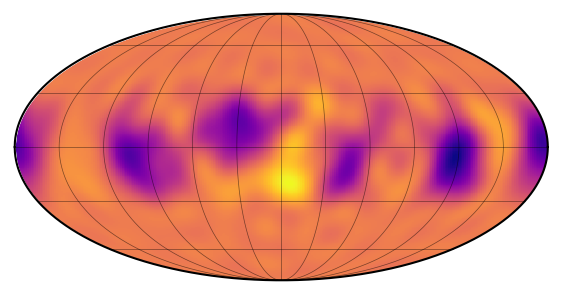

In [59]:
map_true = starry.Map(15,2)
map_true[:,:] = y_true
map_true.show(projection='moll')

Text(0, 0.5, 'flux')

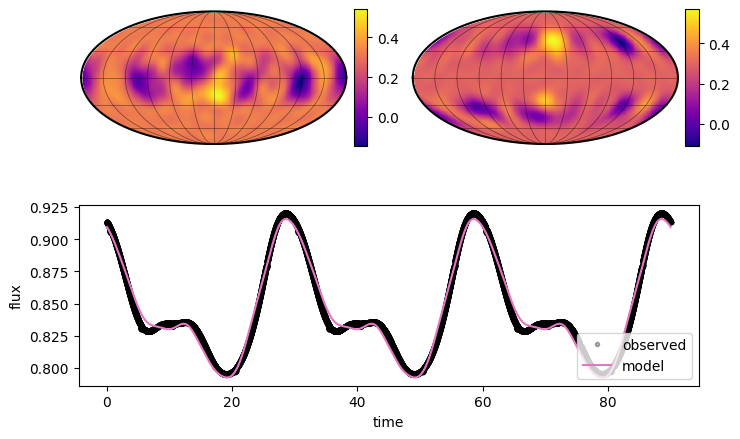

In [61]:
from matplotlib import colors
cmap = plt.get_cmap("plasma")
cmap.set_under("#666666")
cmap.set_over("w")
cnorm = lambda: colors.Normalize(vmin=0.0)
fig = plt.figure(figsize=(8, 8))
fig.subplots_adjust(wspace=0.15)
ax = [
    plt.subplot2grid((3, 2), (0, 0), colspan=1, rowspan=1),
    plt.subplot2grid((3, 2), (0, 1), colspan=1, rowspan=1),
    plt.subplot2grid((3, 2), (1, 0), colspan=2, rowspan=1),
]

# Show the true map
map_true.show(
    ax=ax[0],
    projection="moll",
    colorbar=True,
)

# Show the inferred map
map_inf.show(
    ax=ax[1],
    projection="moll",
    colorbar=True,
)

# Show the flux model
ax[2].plot(t, flux_obs, "k.", alpha=0.3, label="observed")
ax[2].plot(t, map_inf.flux(theta=theta).eval(), "C6", label="model", alpha=1)
ax[2].legend(fontsize=10, loc="lower right")
ax[2].set_xlabel("time")
ax[2].set_ylabel("flux")

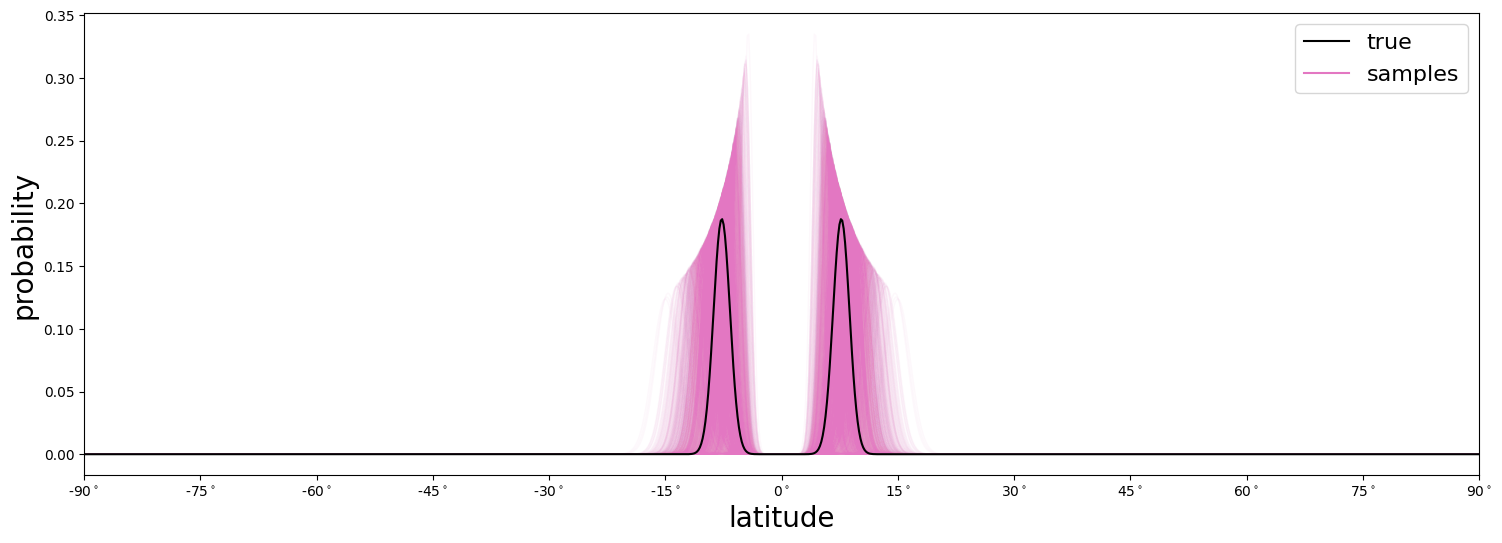

In [82]:
from scipy.stats import norm as Normal

lat=np.linspace(-90., 90., 1000)
nsamples=1000
fig, ax = plt.subplots(1)
fig.set_size_inches(18, 6)
pdf = 0.5 * (
        Normal.pdf(lat, params['sp.mu']['truth'], np.sqrt(params['sp.var']['truth']))
        + Normal.pdf(lat, -params['sp.mu']['truth'], np.sqrt(params['sp.var']['truth']))
    )
for k in range(nsamples):
    ax.plot(lat, 0.5*(Normal.pdf(lat, samples_fromfile.posterior['sp.mu'][0][k], np.sqrt(samples_fromfile.posterior['sp.var'][0][k]))+Normal.pdf(lat, -samples_fromfile.posterior['sp.mu'][0][k], np.sqrt(samples_fromfile.posterior['sp.var'][0][k]))),'C6',lw=1, alpha=0.05, zorder=-1)
ax.plot(lat, pdf,'k',label='true')
ax.plot(lat, np.nan * lat, "C6-", label="samples")
ax.legend(loc="upper right", fontsize=16)
ax.set_xlim(-90, 90)
xticks = [-90, -75, -60, -45, -30, -15, 0, 15, 30, 45, 60, 75, 90]
ax.set_xticks(xticks)
ax.set_xticklabels(["{:d}$^\circ$".format(xt) for xt in xticks])
ax.set_xlabel("latitude", fontsize=20)
ax.set_ylabel("probability", fontsize=20)
plt.savefig("figures/experiment-1-active-lats.pdf", bbox_inches="tight", dpi=300)

In [37]:
import pandas as pd
data_dict = {var: samples_fromfile.posterior[var].values.flatten() for var in free}
samples_df = pd.DataFrame(data_dict, columns=free)

In [38]:
samples_df

,planet.inc,planet.ecc,planet.porb,planet.t0,planet.r,star.inc,star.u1,star.u2,star.prot,star.obl,sp.mu,sp.var,gp.r,gp.c,gp.n
0,88.642135,0.194037,4.999998,0.500020,0.041744,92.093224,0.351948,0.318587,30.000058,29.311244,9.330575,1.294018,9.815086,0.481744,8.276587
1,88.696282,0.196715,5.000016,0.499905,0.041813,95.874830,0.449237,0.214773,29.999968,31.970720,9.177892,1.254353,10.059084,0.437607,8.807900
2,88.819844,0.206016,4.999994,0.500006,0.042390,99.256788,0.258101,0.356645,30.000035,34.887109,6.381183,0.690219,10.380770,0.728056,3.496903
3,88.449332,0.184812,5.000009,0.499913,0.042433,94.491070,0.301528,0.381783,30.000044,32.992320,8.671565,1.138559,10.630561,0.609654,4.161405
4,88.446200,0.184176,5.000005,0.499911,0.041939,93.458434,0.294856,0.382867,30.000044,33.804922,6.801649,0.766831,10.527218,0.555639,6.663074
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,88.506973,0.186209,5.000010,0.499881,0.041880,93.967347,0.311982,0.395805,29.999918,32.288756,5.443666,0.530018,10.126867,0.521428,7.409295
996,88.534184,0.188530,5.000000,0.500086,0.042059,92.664077,0.302618,0.371826,30.000004,29.415148,12.627682,2.014722,10.324179,0.546268,6.705225
997,88.412708,0.181504,5.000000,0.500093,0.042350,92.554644,0.315518,0.396464,29.999999,33.623340,15.007515,2.593409,10.180139,0.371158,7.741191
998,88.552283,0.189081,5.000002,0.500133,0.042603,92.698949,0.321546,0.385756,29.999986,33.394974,14.796486,2.531323,10.127244,0.479160,5.484898


In [73]:
samples_df.columns

Index(['planet.inc', 'planet.ecc', 'planet.porb', 'planet.t0', 'planet.r',
       'star.inc', 'star.u1', 'star.u2', 'star.prot', 'star.obl', 'sp.mu',
       'sp.var', 'gp.r', 'gp.c', 'gp.n'],
      dtype='object')

In [74]:
samples_df['star.inc'] = 180-samples_df['star.inc']

In [75]:
samples_df['star.obl'] = -samples_df['star.obl']

In [76]:
samples_df

,planet.inc,planet.ecc,planet.porb,planet.t0,planet.r,star.inc,star.u1,star.u2,star.prot,star.obl,sp.mu,sp.var,gp.r,gp.c,gp.n
0,88.642135,0.194037,4.999998,0.500020,0.041744,87.906776,0.351948,0.318587,30.000058,-29.311244,9.330575,1.294018,9.815086,0.481744,8.276587
1,88.696282,0.196715,5.000016,0.499905,0.041813,84.125170,0.449237,0.214773,29.999968,-31.970720,9.177892,1.254353,10.059084,0.437607,8.807900
2,88.819844,0.206016,4.999994,0.500006,0.042390,80.743212,0.258101,0.356645,30.000035,-34.887109,6.381183,0.690219,10.380770,0.728056,3.496903
3,88.449332,0.184812,5.000009,0.499913,0.042433,85.508930,0.301528,0.381783,30.000044,-32.992320,8.671565,1.138559,10.630561,0.609654,4.161405
4,88.446200,0.184176,5.000005,0.499911,0.041939,86.541566,0.294856,0.382867,30.000044,-33.804922,6.801649,0.766831,10.527218,0.555639,6.663074
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,88.506973,0.186209,5.000010,0.499881,0.041880,86.032653,0.311982,0.395805,29.999918,-32.288756,5.443666,0.530018,10.126867,0.521428,7.409295
996,88.534184,0.188530,5.000000,0.500086,0.042059,87.335923,0.302618,0.371826,30.000004,-29.415148,12.627682,2.014722,10.324179,0.546268,6.705225
997,88.412708,0.181504,5.000000,0.500093,0.042350,87.445356,0.315518,0.396464,29.999999,-33.623340,15.007515,2.593409,10.180139,0.371158,7.741191
998,88.552283,0.189081,5.000002,0.500133,0.042603,87.301051,0.321546,0.385756,29.999986,-33.394974,14.796486,2.531323,10.127244,0.479160,5.484898


In [79]:
samples_df.columns

Index(['planet.inc', 'planet.ecc', 'planet.porb', 'planet.t0', 'planet.r',
       'star.inc', 'star.u1', 'star.u2', 'star.prot', 'star.obl', 'sp.mu',
       'sp.var', 'gp.r', 'gp.c', 'gp.n'],
      dtype='object')

In [80]:
custom_labels = {
    'planet.inc': r'$i_p$',
    'planet.ecc': r'$e$',
    'planet.porb': r'$P$',
    'planet.t0': r'$t_0$',
    'planet.r': r'$R_p/R_\star$',
    'star.inc': r'$i_\star$',
    'star.u1': r'$u_1$',
    'star.u2': r'$u_2$',
    'star.prot': r'$P_\star$',
    'star.obl': r'$\lambda_\star$',
    'sp.mu': r'$\mu_\phi$',
    'sp.var': r'$\sigma^2_\phi$',
    'gp.r': r'$\mathbb{r}$',
    'gp.c': r'$\mathbb{c}$',
    'gp.n': r'$\mathbb{n}$'
}

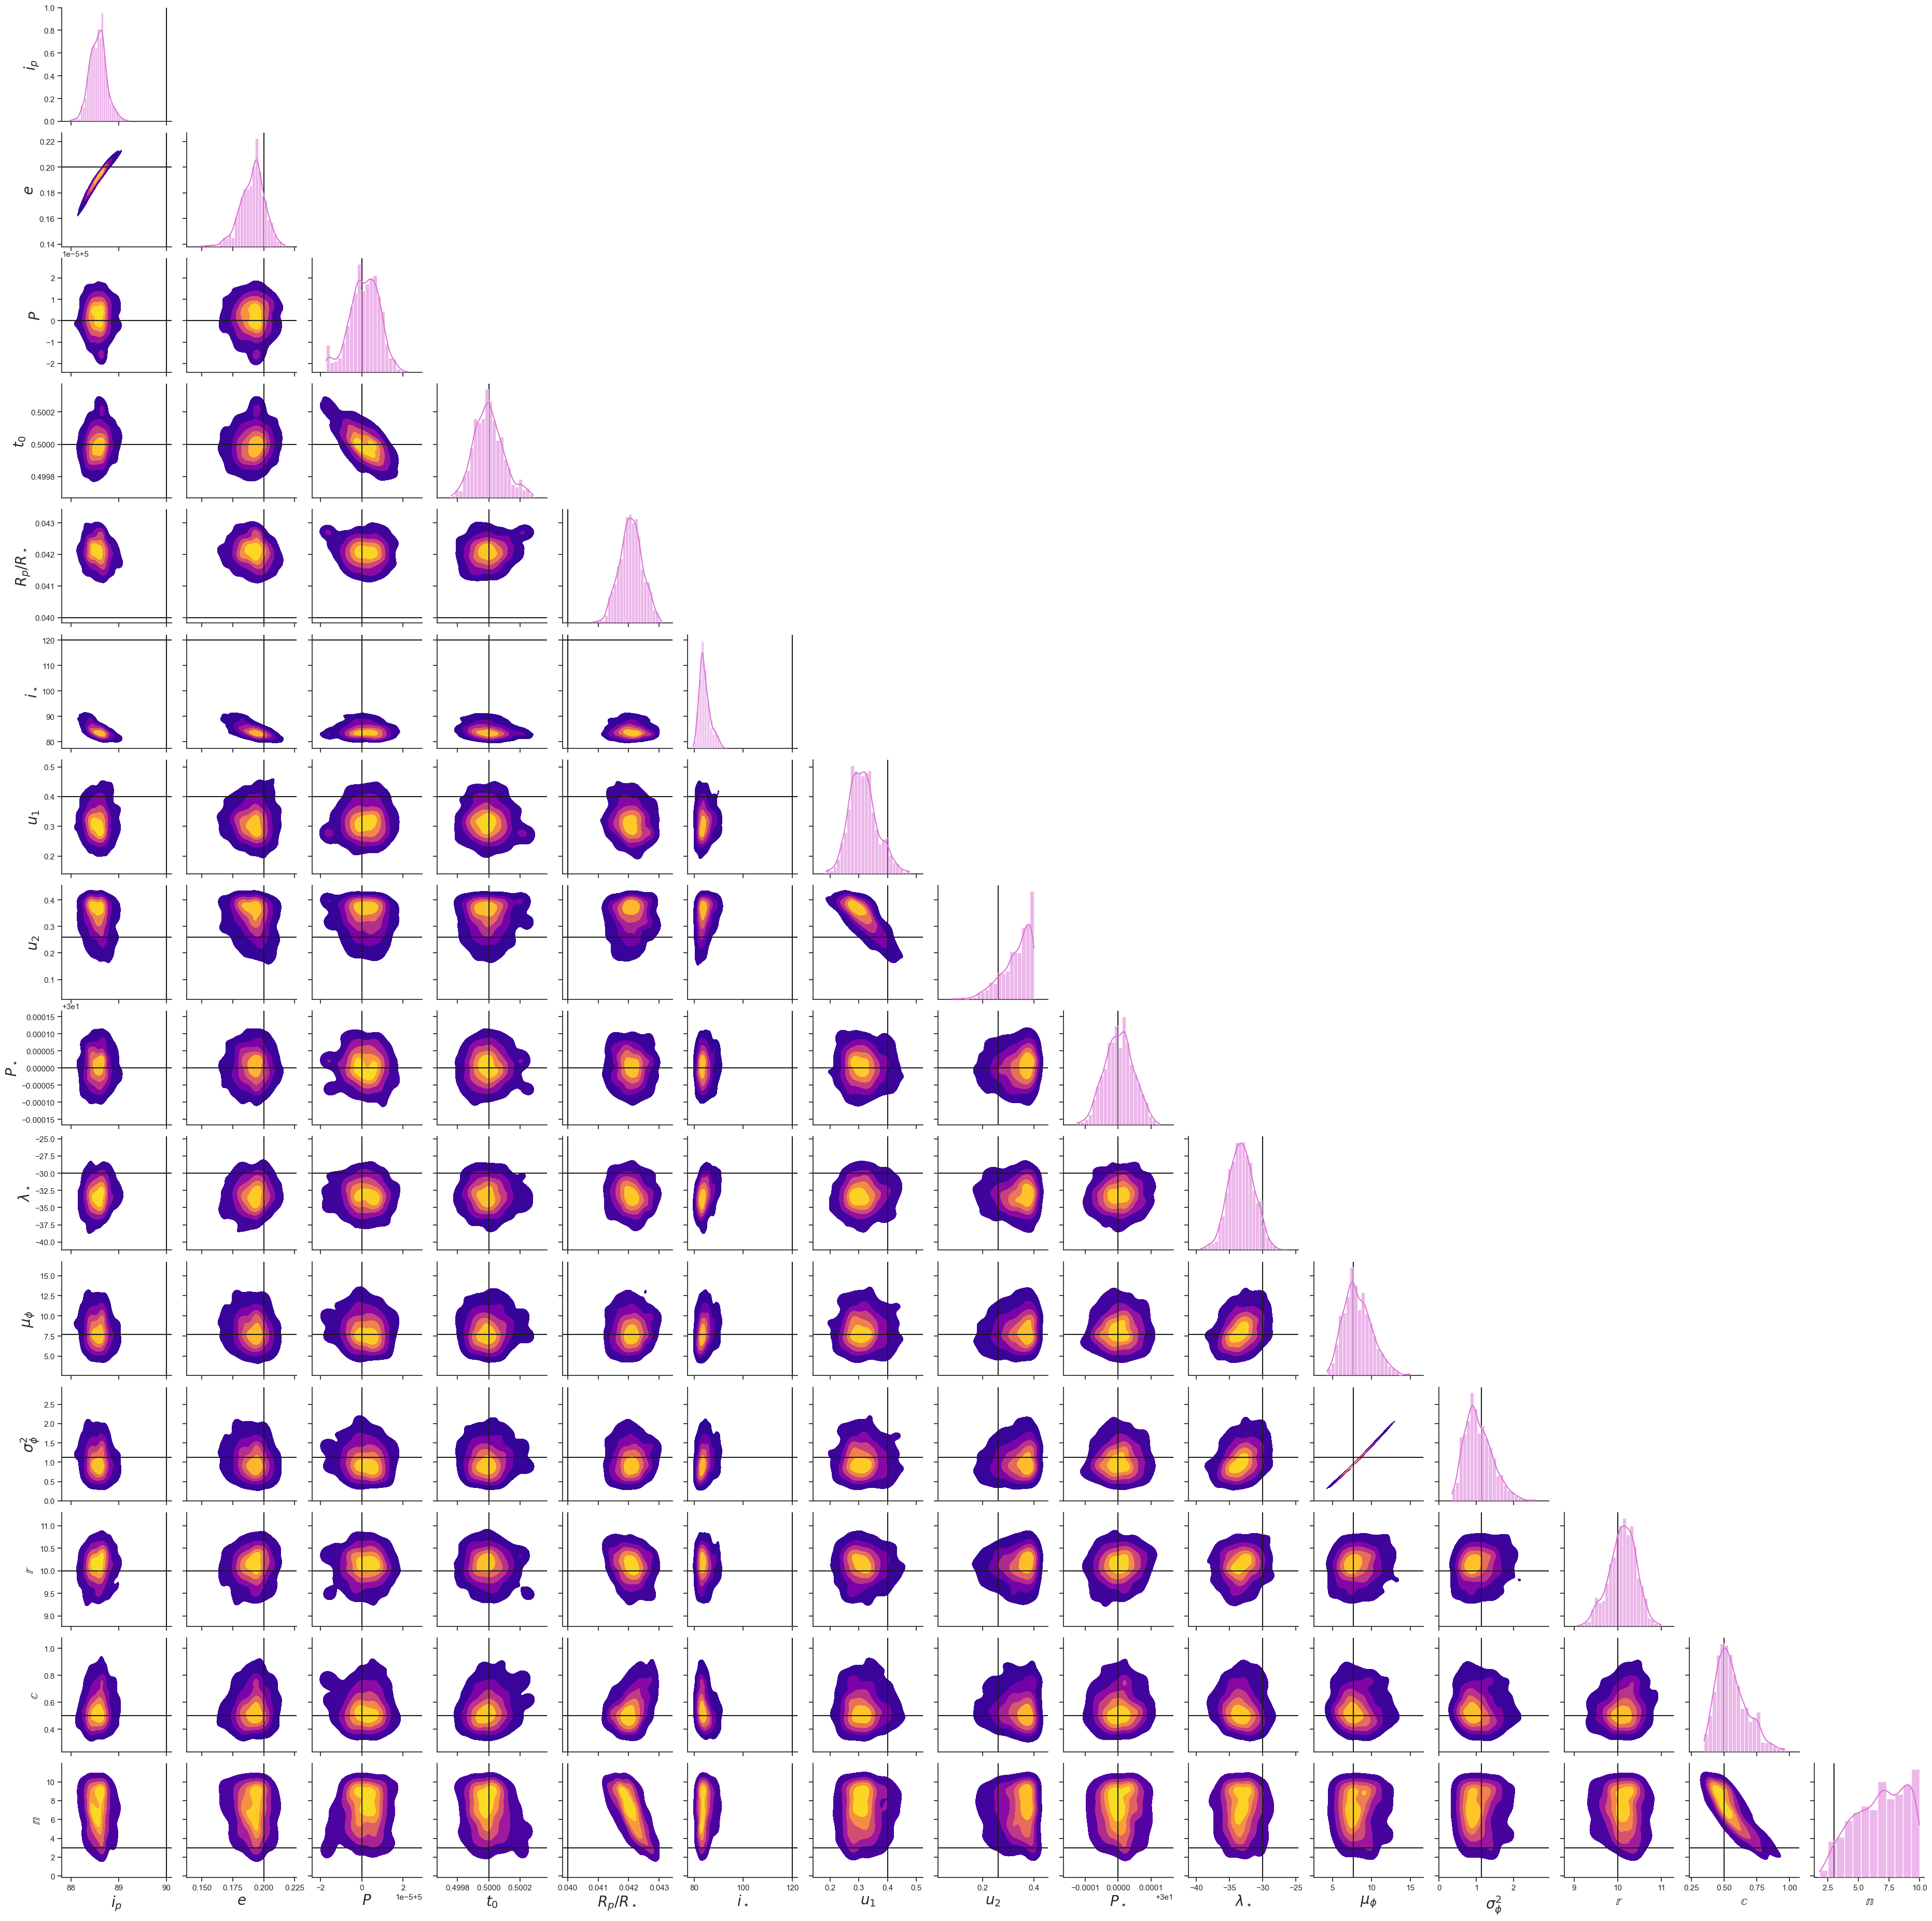

In [82]:
import pandas as pd
import seaborn as sns
sns.set(style='ticks')

# Create the pair grid
g = sns.PairGrid(samples_df, diag_sharey=False)

# Map the histograms to the diagonal
g.map_diag(sns.histplot, kde=True, color='orchid')

# Map the 2D contour plots to the lower triangle
g.map_lower(sns.kdeplot, cmap='plasma', levels=6, fill=True)

# Custom function to remove upper triangle
def remove_upper(*args, **kwargs):
    plt.gca().axis('off')

# Remove the scatter plots and empty axes in the upper triangle
g.map_upper(remove_upper)

for i, var in enumerate(free):
    truth = params[var]['truth']
    # if var == 'star.inc':
    #     truth = 180 - params[var]['truth']
    # if var == 'star.obl':
    #     truth = - params[var]['truth']
    g.axes[i, i].axvline(truth, color='k', linestyle='-')
    # g.axes[i, i].axhline(truth, color='k', linestyle='-')

#     std = np.std(df[var])
#     mean = np.mean(df[var])
#     sigma_plus = mean + 2 * std
#     sigma_minus = mean - 2 * std
#     g.axes[i, i].axvline(sigma_plus, color='k', linestyle='--')
#     g.axes[i, i].axvline(sigma_minus, color='k', linestyle='--')

# Add truth values as lines to the contour plots
for i, y_var in enumerate(free):
    for j, x_var in enumerate(free):
        if j < i:
            truth_x = params[x_var]['truth']
            truth_y = params[y_var]['truth']

            # if y_var == 'star.inc':
            #     truth_y = 180 - params[y_var]['truth']
            # if y_var == 'star.obl':
            #     truth_y = - params[y_var]['truth']

            # if x_var == 'star.inc':
            #     truth_x = 180 - params[x_var]['truth']
            # if x_var == 'star.obl':
            #     truth_x = - params[x_var]['truth']
            
            g.axes[i, j].axvline(truth_x, color='k', linestyle='-')
            g.axes[i, j].axhline(truth_y, color='k', linestyle='-')

for i, var in enumerate(free):
    label = custom_labels.get(var, var)
    g.axes[-1, i].set_xlabel(label, fontsize=20)
    g.axes[i, 0].set_ylabel(label, fontsize=20)

plt.savefig("figures/experiment-1-corner-all.pdf", bbox_inches="tight", dpi=300)

In [62]:
for i, var in enumerate(free):
    truth = params[var]['truth']
    if var == 'star.inc':
        truth = 180 - params[var]['truth']
    if var == 'star.obl':
        truth = -params[var]['truth']

    median = np.median(samples_df[var])
    std = np.std(samples_df[var])
    mean = np.mean(samples_df[var])
    sigma_plus = mean + std
    sigma_minus = mean - std

    print(f'{var}: median = {median}, mean = {mean}, std = {std}, mean +- sigma = [{sigma_minus}, {sigma_plus}]')


planet.inc: median = 88.57139631643521, mean = 88.5698687343231, std = 0.17675426212627368, mean +- sigma = [88.39311447219681, 88.74662299644937]
planet.ecc: median = 0.1921058382145699, mean = 0.19077619243304536, std = 0.00989407912444178, mean +- sigma = [0.18088211330860357, 0.20067027155748715]
planet.porb: median = 5.000001659868149, mean = 5.000001263599602, std = 7.1049415054931295e-06, mean +- sigma = [4.9999941586580965, 5.000008368541107]
planet.t0: median = 0.4999944718335001, mean = 0.5000010602568818, std = 9.31894043307536e-05, mean +- sigma = [0.4999078708525511, 0.5000942496612126]
planet.r: median = 0.0420706059207695, mean = 0.0420719489416952, std = 0.00037391529432860587, mean +- sigma = [0.04169803364736659, 0.042445864236023804]
star.inc: median = 96.08203134634633, mean = 95.61017226315431, std = 2.2769419005684832, mean +- sigma = [93.33323036258582, 97.8871141637228]
star.u1: median = 0.3124933253139707, mean = 0.31624052793833335, std = 0.04859058445195842, 

In [64]:
import numpy as np

for i, var in enumerate(free):
    truth = params[var]['truth']
    if var == 'star.inc':
        truth = 180 - params[var]['truth']
    if var == 'star.obl':
        truth = -params[var]['truth']

    samples = samples_df[var]

    median = np.median(samples)
    std = np.std(samples)
    mean = np.mean(samples)

    lower_bound = np.percentile(samples, 16)
    upper_bound = np.percentile(samples, 84)
    
    print(f'{var}: median = {median}, mean = {mean}, std = {std}, 68% credible interval = [{median - lower_bound}, {upper_bound - median}]')


planet.inc: median = 88.57139631643521, mean = 88.5698687343231, std = 0.17675426212627368, 68% credible interval = [0.1739924513714044, 0.15701319151726523]
planet.ecc: median = 0.1921058382145699, mean = 0.19077619243304536, std = 0.00989407912444178, 68% credible interval = [0.010637680347141742, 0.00805402151768736]
planet.porb: median = 5.000001659868149, mean = 5.000001263599602, std = 7.1049415054931295e-06, 68% credible interval = [7.183149733691607e-06, 6.4520902380849066e-06]
planet.t0: median = 0.4999944718335001, mean = 0.5000010602568818, std = 9.31894043307536e-05, 68% credible interval = [8.290135228428142e-05, 9.347987641405986e-05]
planet.r: median = 0.0420706059207695, mean = 0.0420719489416952, std = 0.00037391529432860587, 68% credible interval = [0.00038297574335072193, 0.00037672837492543076]
star.inc: median = 96.08203134634633, mean = 95.61017226315431, std = 2.2769419005684832, 68% credible interval = [2.635139409897434, 1.607278190699148]
star.u1: median = 0.3

In [69]:
params['star.u2']

{'truth': 0.26,
 'dist': pymc3.distributions.continuous.Uniform,
 'args': [0.0, 0.4]}

<ErrorbarContainer object of 3 artists>

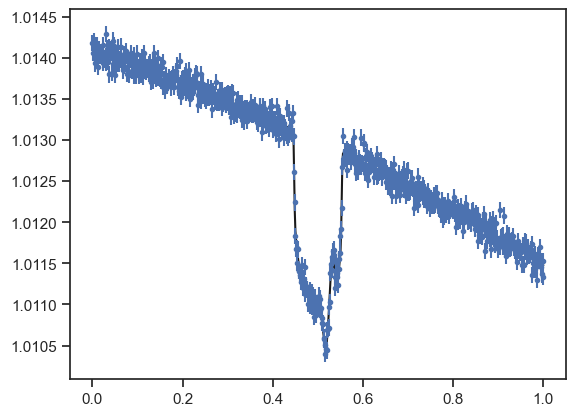

In [92]:
sel = np.abs(t) < 10/10
plt.plot(t[sel], flux_true[sel], color='k')
plt.errorbar(t[sel], flux_obs[sel], yerr=sigma_flux[sel], fmt='.')

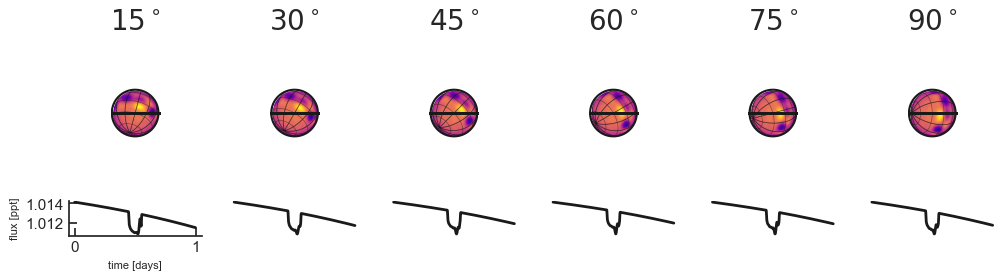

In [93]:
starry.config.lazy = True
obls = [15,30,45,60,75,90]


cmap = plt.get_cmap("plasma_r")
color = lambda i: cmap(0.1 + 0.8 * i / (len(6) - 1))

fig, ax = plt.subplots(
    2,
    len(obls),
    figsize=(12, 2.5),
    gridspec_kw={
        "height_ratios": np.tile([2, 0.5], 1),
        # "width_ratios": np.append(np.ones(5), 0.1),
    },
)

for k in range(len(obls)):
    map = starry.Map(15, 2)
    map.inc = params["star.inc"]["truth"]
    map.obl = -obls[k]
    map[1] = params["star.u1"]["truth"]
    map[2] = params["star.u2"]["truth"]
    star = starry.Primary(map, r=params["star.r"]["truth"], m=params["star.m"]["truth"], prot=params["star.prot"]["truth"]) 
    planet = starry.Secondary(
        starry.Map(0,0),
        inc=params["planet.inc"]["truth"],
        ecc=params["planet.ecc"]["truth"],
        Omega=params["planet.Omega"]["truth"],
        porb=params["planet.porb"]["truth"],
        t0=params["planet.t0"]["truth"],
        r=params["planet.r"]["truth"],
        m=params["planet.m"]["truth"],
        prot=1.0
    )

    sys = starry.System(star, planet)
    xo, yo, zo = sys.position(t)
    xo = xo.eval()[1]
    yo = yo.eval()[1]
    zo = zo.eval()[1]
    theta = (360 * t / params["star.prot"]["truth"]) % 360
        
    sp = StarryProcess(
        a=params["gp.a"]["truth"],
        b=params["gp.b"]["truth"],
        r=params["gp.r"]["truth"],
        c=params["gp.c"]["truth"],
        n=params["gp.n"]["truth"],
    )
    y_true = sp.sample_ylm().eval()[0,:]
    y_true[0] = 1.0

    flux_true = sys.design_matrix(t).eval()[:, :-1] @ y_true
    sigma_flux = 1e-4*np.ones_like(flux_true)

    flux_obs = flux_true + sigma_flux*rng.normal(size=nt)

    # ssp = StarryStarryProcess(sys, sp, nt, len(pri.map.y.eval()))

    map[:,:] = y_true
    map.show(ax=ax[0][k]) 

    xo, yo, zo = sys.position(t)
    xo = xo[1].eval()
    yo = yo[1].eval()
    zo = zo[1].eval()
        
    idx = (zo > 0) | (xo ** 2 + yo ** 2 > 1)
    ax[0][k].plot(xo[idx], yo[idx], "k.", ms=1);
    ax[0][k].set_aspect(1)
    ax[0][k].set_ylim(-3, 3)

    sel = np.abs(t) < 1
    ax[1][k].plot(t[sel], flux_true[sel], color='k', lw=2)

    if k == 0:
            ax[1, k].spines["top"].set_visible(False)
            ax[1, k].spines["right"].set_visible(False)
            ax[1, k].set_xlabel("time [days]", fontsize=8)
            ax[1, k].set_ylabel("flux [ppt]", fontsize=8)
            # for tick in (
            #     ax[1, k].xaxis.get_major_ticks()
            #     + ax[1, k].yaxis.get_major_ticks()
            # ):
            #     tick.label.set_fontsize(6)
            ax[1, k].tick_params(direction="in")
    else:
        ax[1, k].axis("off")
    # Add annotation above each column
    ax[0, k].text(0.5, 1.1, rf"${obls[k]}^\circ$", transform=ax[0, k].transAxes,
                 fontsize=20, ha='center')


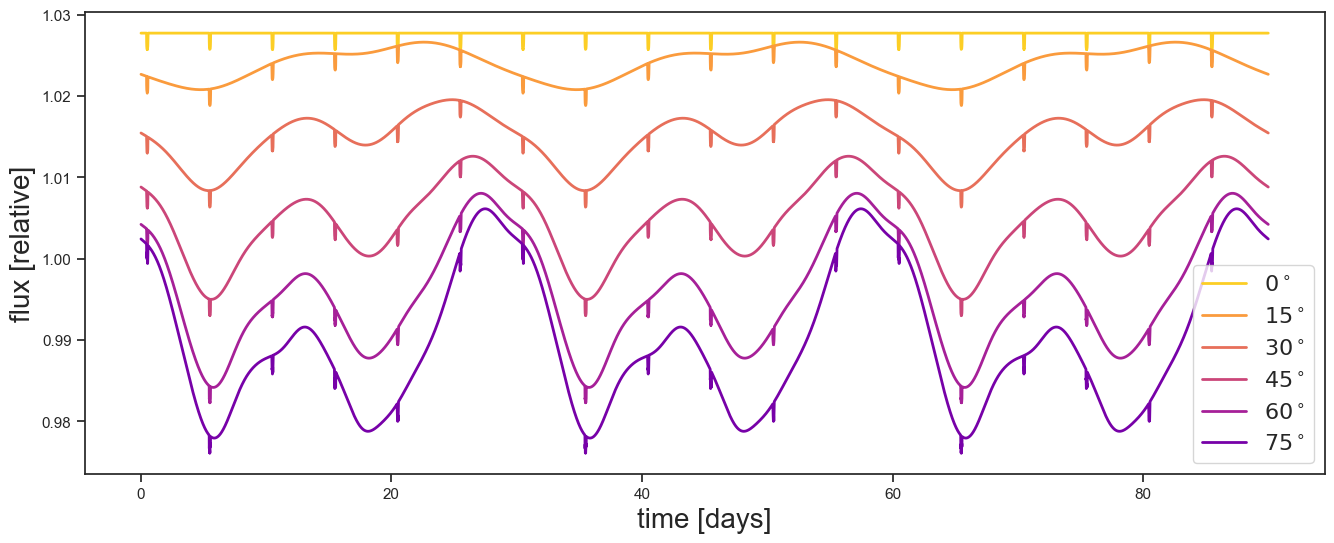

In [102]:
starry.config.lazy = True
incs = [0,15,30,45,60,75,90]

cmap = plt.get_cmap("plasma_r")
color = lambda i: cmap(0.1 + 0.8 * i / (len(incs) - 1))

plt.figure(figsize=(16,6))

for k in range(len(obls)):
    map = starry.Map(15, 2)
    map.inc = incs[k]
    map.obl = 0.0
    map[1] = params["star.u1"]["truth"]
    map[2] = params["star.u2"]["truth"]
    star = starry.Primary(map, r=params["star.r"]["truth"], m=params["star.m"]["truth"], prot=params["star.prot"]["truth"]) 
    planet = starry.Secondary(
        starry.Map(0,0),
        inc=params["planet.inc"]["truth"],
        ecc=params["planet.ecc"]["truth"],
        Omega=params["planet.Omega"]["truth"],
        porb=params["planet.porb"]["truth"],
        t0=params["planet.t0"]["truth"],
        r=params["planet.r"]["truth"],
        m=params["planet.m"]["truth"],
        prot=1.0
    )

    sys = starry.System(star, planet)
    xo, yo, zo = sys.position(t)
    xo = xo.eval()[1]
    yo = yo.eval()[1]
    zo = zo.eval()[1]
    theta = (360 * t / params["star.prot"]["truth"]) % 360
        
    sp = StarryProcess(
        a=params["gp.a"]["truth"],
        b=params["gp.b"]["truth"],
        r=params["gp.r"]["truth"],
        c=params["gp.c"]["truth"],
        n=params["gp.n"]["truth"],
    )
    y_true = sp.sample_ylm().eval()[0,:]
    y_true[0] = 1.0

    flux_true = sys.design_matrix(t).eval()[:, :-1] @ y_true
    sigma_flux = 1e-4*np.ones_like(flux_true)

    flux_obs = flux_true + sigma_flux*rng.normal(size=nt)

    # ssp = StarryStarryProcess(sys, sp, nt, len(pri.map.y.eval()))

    map[:,:] = y_true
    # map.show(ax=ax[0][k]) 

    xo, yo, zo = sys.position(t)
    xo = xo[1].eval()
    yo = yo[1].eval()
    zo = zo[1].eval()
        
    idx = (zo > 0) | (xo ** 2 + yo ** 2 > 1)

    sel = np.abs(t) < 1
    plt.plot(t, flux_true, color=color(k), lw=2, label=rf"${incs[k]}^\circ$")
    plt.legend(fontsize=16)

plt.ylabel("flux [relative]", fontsize=20)
plt.xlabel("time [days]", fontsize=20)
plt.savefig("figures/inclinations.pdf", bbox_inches="tight", dpi=300)


In [108]:
ntransits

18

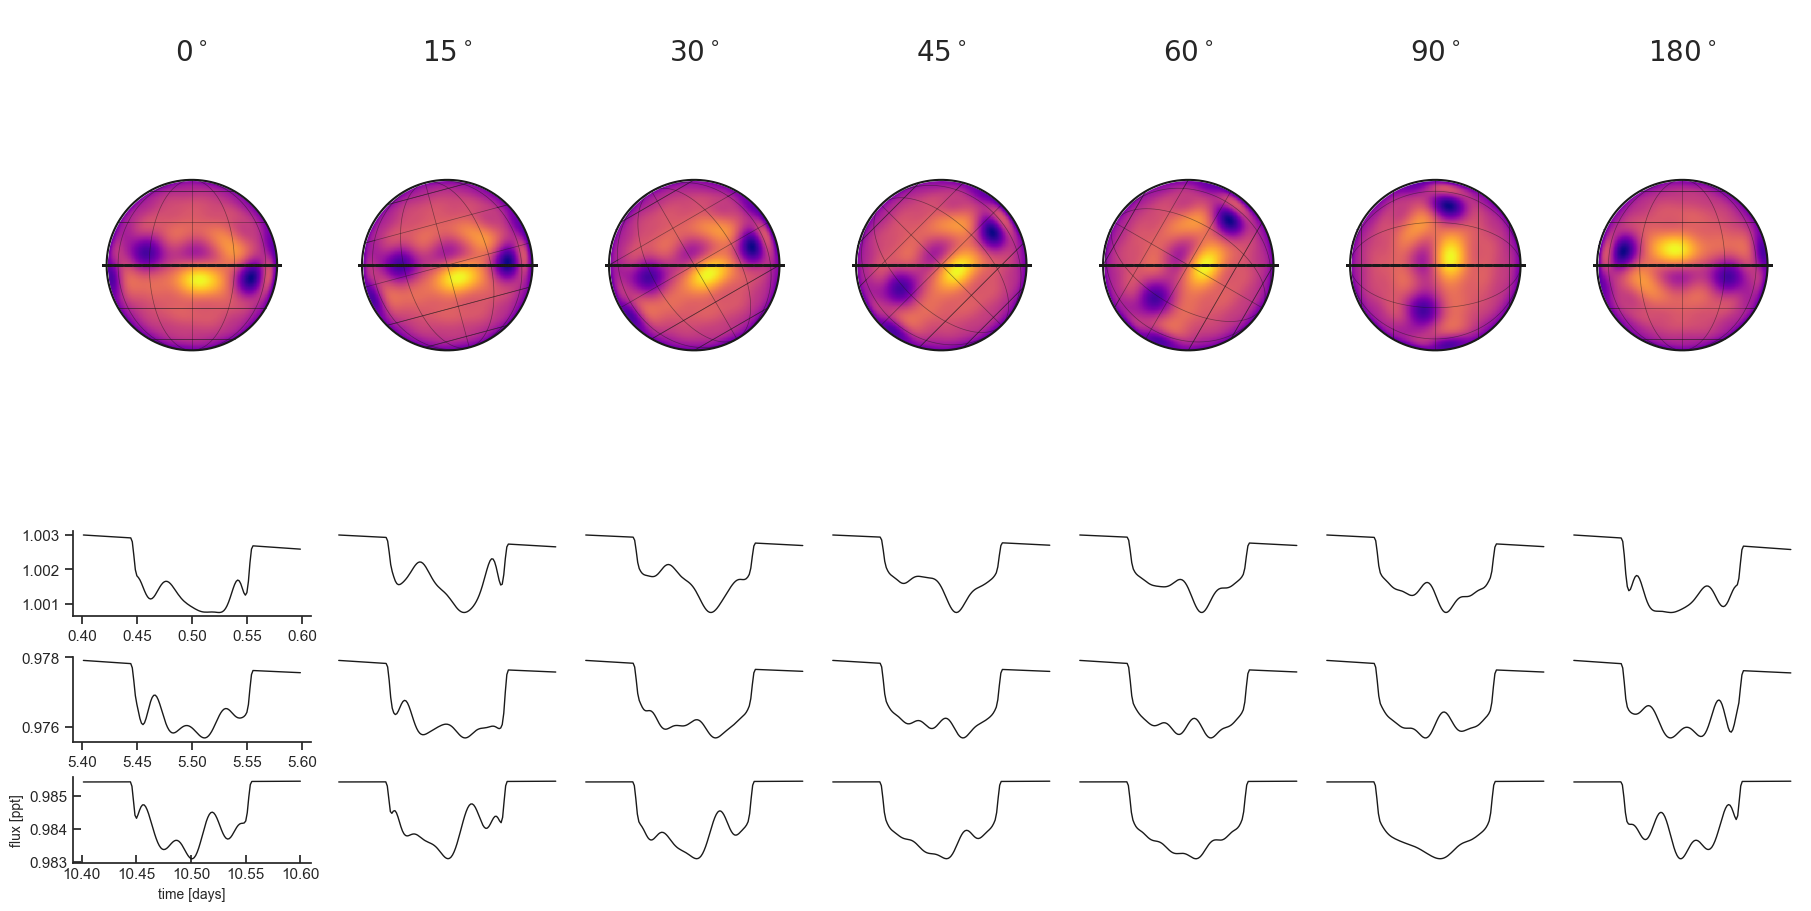

In [132]:
starry.config.lazy = True
obls = [0,15,30,45,60,90,180]

ntransits = int(np.ceil(t[-1] / params['planet.porb']['truth'])) // 6
for n in range(ntransits):
        t0 = 0 + n * params['planet.porb']['truth']
        idx |= ((t > t0 - 0.01) & (t < t0 + 0.01))

cmap = plt.get_cmap("plasma_r")
color = lambda i: cmap(0.1 + 0.8 * i / (len(6) - 1))

fig, ax = plt.subplots(
    # 2+ntransits,
    1+ntransits,
    len(obls),
    figsize=(18, 9),
    gridspec_kw={
        "height_ratios": [3]+[0.5]*ntransits,
    },
    constrained_layout=True,
)


map = starry.Map(15, udeg=2, inc = 90)
sp = StarryProcess(
        a=params["gp.a"]["truth"],
        b=params["gp.b"]["truth"],
        r=params["gp.r"]["truth"],
        c=params["gp.c"]["truth"],
        n=params["gp.n"]["truth"],
    )
y_true = sp.sample_ylm().eval()[0,:]
y_true[0] = 1.0

map[:,:] = y_true

for k in range(len(obls)):
    map.obl = obls[k]
    map[1] = params["star.u1"]["truth"]
    map[2] = params["star.u2"]["truth"]
    star = starry.Primary(map, r=params["star.r"]["truth"], m=params["star.m"]["truth"], prot=params["star.prot"]["truth"]) 
    planet = starry.Secondary(
        starry.Map(0,0),
        inc=params["planet.inc"]["truth"],
        ecc=params["planet.ecc"]["truth"],
        Omega=params["planet.Omega"]["truth"],
        porb=params["planet.porb"]["truth"],
        t0=params["planet.t0"]["truth"],
        r=params["planet.r"]["truth"],
        m=params["planet.m"]["truth"],
        prot=1.0
    )

    sys = starry.System(star, planet)

    flux_true = sys.flux(t, total=False)[0].eval()

    map.show(ax=ax[0][k])

    xo, yo, zo = sys.position(t)
    xo = xo[1].eval()
    yo = yo[1].eval()
    zo = zo[1].eval()
        
    idx = (zo > 0) | (xo ** 2 + yo ** 2 > 1)
    ax[0][k].plot(xo[idx], yo[idx], "k.", ms=1);
    ax[0][k].set_aspect(1)
    ax[0][k].set_ylim(-3, 3)

    for i in range(ntransits):

        idx = (t > planet.t0.eval()+i*planet.porb.eval()-0.1) &  (t<planet.t0.eval()+i*planet.porb.eval()+0.1)
        ax[i+1][k].plot(t[idx], flux_true[idx], color='k', lw=1)
    
        if k == 0:
                ax[i+1, k].spines["top"].set_visible(False)
                ax[i+1, k].spines["right"].set_visible(False)
        else:
            ax[i+1, k].axis("off")
        if k == 0 and i==ntransits-1:
                ax[i+1, k].set_xlabel("time [days]", fontsize=10)
                ax[i+1, k].set_ylabel("flux [ppt]", fontsize=10)
                ax[i+1, k].tick_params(direction="in")
            
    # Add annotation above each column
    ax[0, k].text(0.5, 0.9, rf"${obls[k]}^\circ$", transform=ax[0, k].transAxes,
                 fontsize=20, ha='center')
# plt.tight_layout()
# plt.subplots_adjust(top=0.5)
plt.savefig("figures/obliquities.pdf", bbox_inches="tight", dpi=300)